# Feedback from previous weeks and other and hints

1. Be careful about your environment remembering variables. Make sure your code works in a new _clean_ environment. In Colab: `Runtime`->`restart Runtime`, in Anaconda's Jupyter: `Kernel`->`Restart`.
2. Keep the file names when saving to GitHub. It's always possible to go back to a previous version, you are not losing anything.
3. Run all the cells before saving to GitHub so the output is saved.
4. Graphs without labels (or units when appropriate) are not worth any point.
5. Do put in sufficient explanatory comments in your code.

For this week you can use these imports at the start of your programs:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Introduction

This week we’ll use some of the techniques from the previous weeks (functions, array slicing, ODEs, ...) to see how to solve numerically for the motion of two bodies which attract each other through a gravitational force. While we can use `odeint()` from last week, we will go into some details of numerical solvers, and see which is applicable when by implementing our own solvers. They could then be compared with the ones available in `odeint()`.

The gravitational force example in this sheet can be extended to several bodies, and since both gravitational and electrostatic forces have a $1/r^2$ distance dependence, the methods used here can be applied also to the case of a number of interacting charged objects.

A numerical study is important since only the very simplest cases have an analytic solution - even just three interacting bodies cannot in general be solved analytically. We first look at the simplest analytically solvable case, that of circular orbits, which you met in PX1121 last year.

## Circular Newtonian orbits - revision

If two bodies are separated by a distance $r$ and interact through gravity, then the force $\mathbf{F_G}$ acting on a body of mass $m$ due to a body of mass $M$ is:

$$
\mathbf{F}_G = - \frac{GMm}{r^2}\hat{\mathbf{r}}
$$

where $\mathbf{\hat{r}}$ is unit vector pointing from the body of mass $M$ to the body of mass $m$.

We shall take the case where the mass $m \ll M$ to simplify the subsequent equations. So we can treat the position of mass M as fixed at the origin. (To solve the more general case analytically, the concept of reduced mass needs to be introduced, which you will meet in another module.)

There are many different possible paths or 'orbits' that the small mass can take, depending on its _initial conditions_. In general it will follow an elliptical orbit of size and eccentricity which can be calculated knowing these initial conditions $\mathbf{r}_0$ and $\mathbf{v}_0$.

In the special case of circular motion, the initial velocity $\mathbf{v}_0$ is perpendicular to $\mathbf{r}_0$ and of the correct magnitude to produce an exactly circular orbit. The centripetal force acting on $m$ is

$$
\mathbf{F}_c = - \frac{mv^2}{r}\hat{\mathbf{r}}
$$

Equating $\mathbf{F}_G = \mathbf{F}_c$ and noting that for circular motion the speed can be related to the angular speed $\omega$ by $v = r\omega$, then we can derive that

$$
\omega^2=\frac{GM}{r^3}
$$

The angular speed is just the rate of change of the angle $\phi$, and since $\omega$ is a constant (for circular motion $r$ does not change!), the angle (or 'phase') as a function of time is $\phi = \omega t$. We can express the motion in two dimensions as (assuming that at $t = 0$ the location is $x=0,y=r$),

$$
\begin{aligned}
x(t) = r \sin(\omega t),\,\, y(t) = r \cos(\omega t)
\end{aligned}
$$

which can be plotted.

## General 2D Newtonian orbits

But orbits are not necessarily circular. We now extend the problem to arbitrary initial conditions. It’s possible to solve this analytically, but we go straight to exploring numerical methods.

The equation of motion of mass $m \ll M$ is

$$
\frac{d^2 \mathbf{r}}{dt^2}=-\frac{GMm}{r^2}\hat{\mathbf{r}}
$$

(Note: breaking this up into components gives two equations

$$
\begin{aligned}
\frac{d^2 x}{dt^2} & = -\frac{GMx}{r^3} \\
\frac{d^2 y}{dt^2} & = -\frac{GMy}{r^3}
\end{aligned}
$$

As we are dealing with only two bodies, and the forces are central, it’s clear that the motion is in a 2D plane, so we don’t need a $z$ component of motion.)

# Our goals

You will solve the last equation using several methods. The goals of the exercises are to

 1. Workout how to solve (i.e. to integrate) the equations of motion above using various methods.


 2. Compare their relative accuracy.


 3. Understand the consequences of different choices of initial conditions – circular orbits and eccentric orbits.


 4. See how to extend to another simple dynamical problem

You will implement three different integration schemes and look at how accurately they solve the orbit equations.

# Basic numerical approach

One way to solve the second order equations of motion is to break it down into two coupled first-order equations. This can be done as follows:

$$
\begin{aligned}
d\mathbf{r}/dt & = \mathbf{v} \\
d\mathbf{v}/dt & = \mathbf{a} = -GM\mathbf{r}/r^3
\end{aligned}
$$

Given some initial positions $\mathbf{r}(t = 0) = [x(0), y(0)]$, and initial velocity components $\mathbf{v}(t = 0) = [v_x(0),v_y(0)]$, then we integrate the first equation to get an update on the position, and the second equation to get an update on the velocity, at the next time step $\Delta t$ later. We then repeat this for subsequent time steps. Let’s see three methods by which this can be done:


## I Euler’s method

The simplest integration method is Euler’s method, which you used in Week 9 of PX1224 last year. The update scheme is (_ensure that you understand this_):

$$
\begin{aligned}
\mathbf{r}(t + \Delta t) & = \mathbf{r}(t) + \mathbf{v}(t)\Delta t \\
\mathbf{v}(t + \Delta t) & = \mathbf{v}(t) + \mathbf{a}(t)\Delta t
\end{aligned}
$$

## II Euler-Cromer method

In the Euler-Cromer method, we update the velocity first, and then use the new velocity to update the position. i.e.,

$$
\begin{aligned}
\mathbf{v}(t + \Delta t) & = \mathbf{v}(t) + \mathbf{a}(t)\Delta t \\
\mathbf{r}(t + \Delta t) & = \mathbf{r}(t) + \mathbf{v}(t + \Delta t)\Delta t
\end{aligned}
$$

An even better method is ...

## III Verlet method

This was popularised by Loup Verlet in 1967 (although first discovered two centuries before) for molecular dynamics simulations. It is very important nowadays for calculating such things as the interaction of large molecules (e.g. for developing theraputic drugs).

The method can be written as

$$
\begin{aligned}
\mathbf{r}(t + \Delta t) & = \mathbf{r}(t) + \mathbf{v}(t)\Delta t + (1/2)\mathbf{a}(t)\Delta t^2 \\
\mathbf{v}(t + \Delta t) & = \mathbf{v}(t) + 1/2 [\mathbf{a}(t)+\mathbf{a}(t + \Delta t)]\Delta t
\end{aligned}
$$

Strictly speaking, this is called the 'velocity Verlet' method. (It is closely related to the so-called 'leapfrog' method.)

So you need to evaluate the acceleration $\mathbf{a}$ at the current point (time $t$) and the next point (time $t+\Delta t$). Since $\mathbf{a}$ depends only on position $\mathbf{r}$ in our case of orbits, this is straightforward because the next position is calculated in the first line.

The clever thing about the integrator is that it is time-reversible, and this means that the energy of the system is in principle exactly (not just approximately) conserved. This leads to huge improvements in accuracy.

# How to program these methods

**Note**: If you are still a little unsure about using functions, _now_ is the time to revise, ask a demonstrator, and go to office hours.

To implement and compare the above methods you should create a general `orbit_solve` function, that will solve your equations for any choice of initial conditions `r0` and `v0`, integration time `tmax` , number of integration points `N` , and (eventually) choice of numerical method.

Since $\mathbf{r}$ and $\mathbf{v}$ are vectors, we write their x- and y-components with the help of a numpy array. The initial conditions `r0` and `v0` will each be length-2 numpy arrays (representing the 2D vectors) that contains the initial position and initial velocity vectors. For example

In [2]:
# some purely arbitrary values !
r0 = [1, 0] # positive x-component only set to 1
v0 = [0 , 0.3] # negative y-component only set to 0.3

So the `orbit_solve` function would be structured like this (where we use `r[i]` for $\mathbf{r}(t)$, `r[i+1]` for $\mathbf{r}(t + \Delta t)$ and so on):

```python
def orbit_solve (r0, v0, tmax, N, method = 'euler'):
    # set-up the time-step using tmax and N:
    ...
    # set up an array for the output times (using tmax, time-step and N):
    ...
    # set up arrays for the positions and velocities (see below)
    ...
    # include the initial conditions in the arrays
    ...
    # then do the integration for all the integration points
    for i in range (0, N-1):
        r[i+1] = ....
        v[i+1] = ....
    # output the solution (arrays for positions and velocities) versus time
    return t, r, v
```

Include the `method` keyword since you will modify this function shortly. (You will use `if` statements to get the code to use the desired integrator, so that the one `orbit_solve` function can call an Euler, Euler-Cromer or Verlet integrator, depending on the choice input into the `orbit_solve` function.)

The returned values `t`, `r` and `v` should be length-N arrays of the time, position vector, and velocity vector at each time step of the integration (i = 0, 1, 2, ... N-1).

**Help on the vectors**: It’s easy to get confused when dealing with a length-N array (representing N time steps) of length-2 arrays (representing the x- and y-components of vectors).

To define an array r of 2D vectors of length N for example, you can write

In [3]:
N = 10
r = np.zeros((N,2)) # N rows (time step), 2 columns (x- and y-components)
v = np.zeros((N,2)) # same shape for v

So, with `N` equal to 10, `r` looks like this:

In [4]:
r

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])

Going down the rows is equivalent to stepping in time. The first row of `r` (corresponding to zero time) is `r[0]`,

In [5]:
r[0]

array([0., 0.])

which we can change:

In [6]:
x0=10
y0=0
r[0]=[x0,y0]

print(r[0])

[10.  0.]


The first element of this row (corresponding to the x-component) is `r[0][0]`, or alternatively `r[0,0]`,

In [7]:
r[0,0]

np.float64(10.0)

To get all the rows of column 0, you would use `r[:,0]`

In [8]:
r[:,0]

array([10.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.])

which is returned as a 1D array, ready for plotting. Thus, these arrays can then be plotted after the solution has been produced.

# Exercises

This must be marked before you leave the lab. Mark weighting is in brackets. **Save your work to GitHub after having run all cells with `Runtime` -> `Restart and run all`. And do not change the notebook's filename.** Do add comments to your code, you'll lose points if your code is hard to understand. Graphs without labels (or units when appropriate) are not worth any point.

## Exercise 0

See LearningCentral for an example using the [Lotka-Volterra equations](https://en.wikipedia.org/wiki/Lotka%E2%80%93Volterra_equations).

## Exercise 1
[6] Complete the orbit_solve function above to implement the Euler method.

In [9]:
G = 1.0
M = 1.0

def orbit_solve(r0, v0, tmax, N, method='euler'):
    # Set-up the time-step
    dt = tmax / (N - 1)

    # Set up an array for the output times
    t = np.linspace(0, tmax, N)

    # Set up arrays for the positions and velocities
    r = np.zeros((N, 2))
    v = np.zeros((N, 2))

    # Include the initial conditions in the arrays
    r[0] = np.array(r0)
    v[0] = np.array(v0)

    # Define acceleration function
    def acceleration(pos):
        r_magnitude = np.linalg.norm(pos)
        if r_magnitude == 0:
            return np.array([0.0, 0.0]) # Avoid division by zero at origin
        return -G * M * pos / (r_magnitude**3)

    # Perform integration
    for i in range(N - 1):
        if method == 'euler':
            # Euler's method
            a_i = acceleration(r[i])
            r[i+1] = r[i] + v[i] * dt
            v[i+1] = v[i] + a_i * dt
        elif method == 'euler-cromer':
            # Euler-Cromer method
            a_i = acceleration(r[i])
            v[i+1] = v[i] + a_i * dt
            r[i+1] = r[i] + v[i+1] * dt
        elif method == 'verlet':
            # Verlet method
            a_i = acceleration(r[i])
            r[i+1] = r[i] + v[i] * dt + 0.5 * a_i * dt**2
            a_i_plus_1 = acceleration(r[i+1]) # Acceleration at the new position
            v[i+1] = v[i] + 0.5 * (a_i + a_i_plus_1) * dt
        else:
            raise ValueError(f"Unknown method: {method}")

    # Output the solution
    return t, r, v

## Exercise 2
[4] Use your function to solve the 2D equations of motion for a circular orbit. For simplicity, you can set $G = 1$ and $M = 1$. Calculate the time period for one orbit and integrate the equations for a few (say two) periods, and 100 points, and plot the (x,y) motion. Does this look like what you expect? How does this change if N is 200 and 400? (Plot all in one figure.)

  **Hint**: To get the right initial conditions for a circular orbit you can do the following. Choose some separation, and some initial position (for example, $r = 10$ and $x(0) = 10$ and $y(0) = 0$). Then calculate the theoretical value of $\omega$ for a circular orbit, and hence the appropriate initial values of $v_x(0)$ and $v_y(0)$. Note that the velocity vector will be perpendicular to the position vector for a circular orbit. You can work out what the time period $T$ is for one orbit, and choose a time step a multiple of $\Delta t = T/100$ etc.


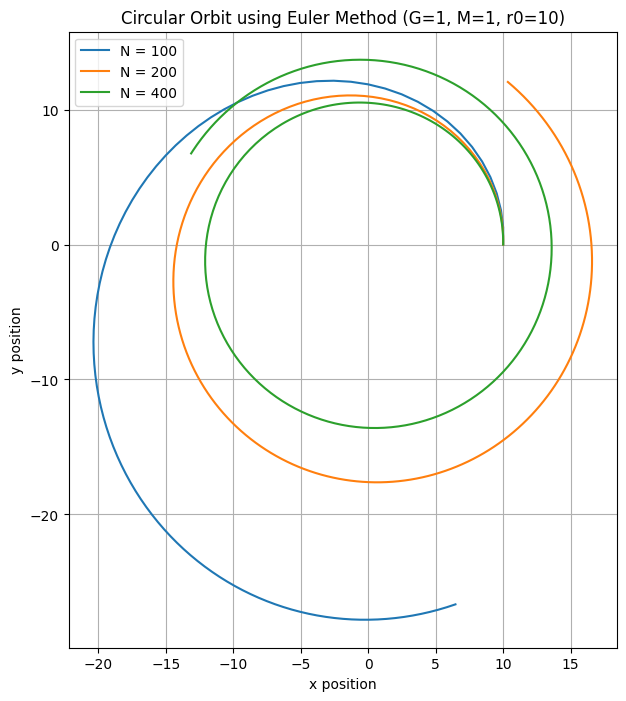

In [10]:
# Exercise 2: Circular Orbit using Euler's Method

# Define constants (already defined in the previous cell, but good to be explicit)
G = 1.0
M = 1.0

# Choose an initial separation (radius)
r0_magnitude = 10.0

# Calculate theoretical angular speed for a circular orbit: omega^2 = GM/r^3
omega = np.sqrt(G * M / (r0_magnitude**3))

# Calculate the time period for one orbit: T = 2 * pi / omega
T = 2 * np.pi / omega

# Set initial conditions for a circular orbit
# Initial position: (r0_magnitude, 0)
r0 = np.array([r0_magnitude, 0.0])

# Initial velocity: perpendicular to position, magnitude v = r * omega
# For initial position (r, 0), velocity should be (0, r * omega) for counter-clockwise motion
v0 = np.array([0.0, r0_magnitude * omega])

# Define the maximum time for integration (e.g., two periods)
tmax = 2 * T

# List of N values to test
N_values = [100, 200, 400]

plt.figure(figsize=(8, 8))

for N in N_values:
    # Integrate the equations of motion using Euler's method
    t, r, v = orbit_solve(r0, v0, tmax, N, method='euler')

    # Plot the (x,y) motion
    plt.plot(r[:, 0], r[:, 1], label=f'N = {N}')

plt.xlabel('x position')
plt.ylabel('y position')
plt.title('Circular Orbit using Euler Method (G=1, M=1, r0=10)')
plt.gca().set_aspect('equal', adjustable='box') # Ensure circular orbits look circular
plt.grid(True)
plt.legend()
plt.show()


## Exercise 3

[6] Modify your function to include both the Euler-Cromer method and the Verlet method. The method keyword in the function should be used to select the integration method used in the function (using an `if` statement).

In [11]:
G = 1.0
M = 1.0

def orbit_solve(r0, v0, tmax, N, method='euler'):
    # Set-up the time-step
    dt = tmax / (N - 1)

    # Set up an array for the output times
    t = np.linspace(0, tmax, N)

    # Set up arrays for the positions and velocities
    r = np.zeros((N, 2))
    v = np.zeros((N, 2))

    # Include the initial conditions in the arrays
    r[0] = np.array(r0)
    v[0] = np.array(v0)

    # Define acceleration function
    def acceleration(pos):
        r_magnitude = np.linalg.norm(pos)
        if r_magnitude == 0:
            return np.array([0.0, 0.0]) # Avoid division by zero at origin
        return -G * M * pos / (r_magnitude**3)

    # Perform integration
    for i in range(N - 1):
        if method == 'euler':
            # Euler's method
            a_i = acceleration(r[i])
            r[i+1] = r[i] + v[i] * dt
            v[i+1] = v[i] + a_i * dt
        elif method == 'euler-cromer':
            # Euler-Cromer method
            a_i = acceleration(r[i])
            v[i+1] = v[i] + a_i * dt
            r[i+1] = r[i] + v[i+1] * dt
        elif method == 'verlet':
            # Verlet method
            a_i = acceleration(r[i])
            r[i+1] = r[i] + v[i] * dt + 0.5 * a_i * dt**2
            # Note: acceleration for r[i+1] must be calculated after r[i+1] is known
            a_i_plus_1 = acceleration(r[i+1])
            v[i+1] = v[i] + 0.5 * (a_i + a_i_plus_1) * dt
        else:
            raise ValueError(f"Unknown method: {method}")

    # Output the solution
    return t, r, v

## Exercise 4

[4] Compare the Euler, Euler-Cromer and Verlet method by plotting a graph for a given number of points. Again, choose just a few orbits.


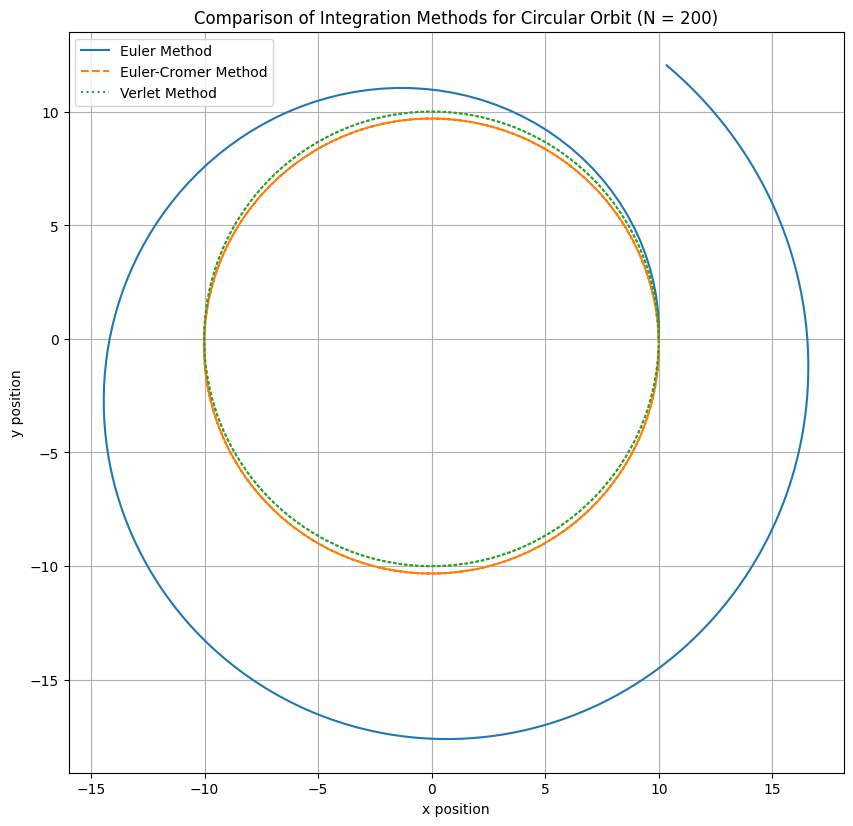

In [12]:
# Exercise 4: Compare Euler, Euler-Cromer, and Verlet methods

# Define constants (already defined globally)
G = 1.0
M = 1.0

# Initial conditions for a circular orbit (as determined in Exercise 2)
r0_magnitude = 10.0
omega = np.sqrt(G * M / (r0_magnitude**3))
T = 2 * np.pi / omega

r0 = np.array([r0_magnitude, 0.0])
v0 = np.array([0.0, r0_magnitude * omega])

# Define the maximum time for integration (e.g., two periods)
tmax = 2 * T

# Number of integration points (choose one N for comparison)
N_compare = 200 # Using a moderate N for comparison

plt.figure(figsize=(10, 10))

# Simulate and plot using Euler's method
t_euler, r_euler, v_euler = orbit_solve(r0, v0, tmax, N_compare, method='euler')
plt.plot(r_euler[:, 0], r_euler[:, 1], label='Euler Method', linestyle='-')

# Simulate and plot using Euler-Cromer method
t_ec, r_ec, v_ec = orbit_solve(r0, v0, tmax, N_compare, method='euler-cromer')
plt.plot(r_ec[:, 0], r_ec[:, 1], label='Euler-Cromer Method', linestyle='--')

# Simulate and plot using Verlet method
t_verlet, r_verlet, v_verlet = orbit_solve(r0, v0, tmax, N_compare, method='verlet')
plt.plot(r_verlet[:, 0], r_verlet[:, 1], label='Verlet Method', linestyle=':')

plt.xlabel('x position')
plt.ylabel('y position')
plt.title(f'Comparison of Integration Methods for Circular Orbit (N = {N_compare})')
plt.gca().set_aspect('equal', adjustable='box') # Ensure circular orbits look circular
plt.grid(True)
plt.legend()
plt.show()

## Exercise 5

Not marked, but useful to check your results: modify your function to also include the [odeint](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.odeint.html) function (which uses Adams methods (predictor-corrector) in the nonstiff case, and Backward Differentiation Formula (BDF) methods (the Gear methods) in the stiff case). Compare your results. You can also add the newer [solve_ivp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html) function from scipy, which itself includes many integration methods.

## Exercise 6

Not marked. If you have time, explore some elliptical orbits.

## Exercise 7

Not marked. If you still have time, it’s useful to plot out the total energy of the mass $m$ versus time. Do this for 10 orbits this time, and 200 points.

 **Hint**: The total energy is just $E = T + V = mv^2/2+V(r) = mv^2/2 - G M m/r$ . So it’s easy to find the energy against time (as an array) given the position and velocity arrays. (Pick a mass $m = 1$ since it only scales the energy and doesn’t change the equations of motion as we have fixed $M$ anyway.)

In [13]:
HERE

NameError: name 'HERE' is not defined

# Task
Provide a comprehensive explanation of the provided exercise sheet, suitable for exam preparation. This explanation should cover:
1.  **Key Physics and Mathematical Concepts**: Discuss Newtonian gravity, circular orbits, the transformation of second-order ODEs into coupled first-order ODEs, and the initial conditions for orbits.
2.  **Numerical Integration Methods**: Detail the principles and update equations for Euler's method, Euler-Cromer's method, and the Verlet method, highlighting their differences and advantages.
3.  **Core Code Structures**: Explain the `orbit_solve` function, its parameters (`r0`, `v0`, `tmax`, `N`, `method`), its internal logic for handling different integration methods, the role of the `acceleration` helper function, and how `numpy` arrays are used for storing time-series data.
4.  **Copy-Pastable Code Snippets**: Include all necessary code, clearly marked, such as imports, the complete `orbit_solve` function, the `acceleration` function (as defined within `orbit_solve`), code for setting up circular orbit initial conditions, and basic plotting commands.

The final output should be a single, structured markdown text block containing all the requested information.

## Extract Key Concepts

### Subtask:
Identify and list all fundamental physics principles and mathematical concepts discussed in the exercise sheet, such as Newtonian gravity, circular orbits, and the breakdown of second-order ODEs into first-order ones.


### Identified Key Concepts

Based on the 'Introduction', 'Circular Newtonian orbits - revision', 'General 2D Newtonian orbits', and 'Basic numerical approach' sections of the exercise sheet, the following fundamental physics principles and mathematical concepts are discussed:

1.  **Newtonian Gravity Principle:**
    *   **Force Equation**: The gravitational force $\mathbf{F}_G$ between two bodies of mass $m$ and $M$ separated by distance $r$ is given by $\mathbf{F}_G = - \frac{GMm}{r^2}\hat{\mathbf{r}}$, where $\hat{\mathbf{r}}$ is a unit vector pointing from $M$ to $m$.
    *   **Assumption**: For simplification, it is assumed that $m \ll M$, allowing the mass $M$ to be considered fixed at the origin.

2.  **Circular Orbits (Special Case):**
    *   **Centripetal Force**: For circular motion, the centripetal force is $\mathbf{F}_c = - \frac{mv^2}{r}\hat{\mathbf{r}}$.
    *   **Equating Forces**: By equating gravitational and centripetal forces, and using $v = r\omega$, the relationship for angular speed $\omega$ is derived as $\omega^2=\frac{GM}{r^3}$.
    *   **Time Period**: The time period $T$ for one orbit is related to the angular speed by $T = 2\pi / \omega$.
    *   **Position Equations**: For a circular orbit, assuming initial position $(0, r)$ at $t=0$, the motion in two dimensions is described by $x(t) = r \sin(\omega t)$ and $y(t) = r \cos(\omega t)$.
    *   **Initial Conditions**: For a circular orbit, the initial velocity $\mathbf{v}_0$ must be perpendicular to $\mathbf{r}_0$ and have a specific magnitude.

3.  **General 2D Newtonian Orbits and Equations of Motion:**
    *   **Second-Order Differential Equation**: The equation of motion for mass $m$ is given by $\frac{d^2 \mathbf{r}}{dt^2}=-\frac{GMm}{r^2}\hat{\mathbf{r}}$.
    *   **Component Form**: This can be broken into two components:
        *   $\frac{d^2 x}{dt^2} = -\frac{GMx}{r^3}$
        *   $\frac{d^2 y}{dt^2} = -\frac{GMy}{r^3}$
    *   **2D Motion**: The motion is confined to a 2D plane due to central forces.

4.  **Transformation to Coupled First-Order Differential Equations:**
    *   **Breakdown**: The second-order equation of motion is transformed into two coupled first-order equations to facilitate numerical integration:
        *   $\frac{d\mathbf{r}}{dt} = \mathbf{v}$ (velocity definition)
        *   $\frac{d\mathbf{v}}{dt} = \mathbf{a} = -GM\mathbf{r}/r^3$ (acceleration due to gravity)

5.  **Initial Conditions:**
    *   **Importance**: The initial positions $\mathbf{r}(t = 0) = [x(0), y(0)]$ and initial velocity components $\mathbf{v}(t = 0) = [v_x(0),v_y(0)]$ are crucial for determining the specific path or 'orbit' the small mass will take.

6.  **Numerical Integration Methods (Overview):**
    *   The document introduces three methods for numerically solving these first-order equations: Euler's method, Euler-Cromer method, and Verlet method. These methods provide update schemes for position and velocity at each time step $\Delta t$.

## Describe Numerical Methods

### Subtask:
Provide a detailed explanation of each numerical integration method (Euler, Euler-Cromer, and Verlet) introduced in the notebook, including their underlying principles and update equations.


## Describe Numerical Methods

### Subtask:
Provide a detailed explanation of each numerical integration method (Euler, Euler-Cromer, and Verlet) introduced in the notebook, including their underlying principles and update equations.

### General Numerical Approach

The fundamental idea for numerically solving a second-order ordinary differential equation (ODE) like the equation of motion $\frac{d^2 \mathbf{r}}{dt^2} = \mathbf{a}(\mathbf{r})$ is to break it down into a system of two coupled first-order ODEs. This is achieved by introducing velocity as an intermediate variable:

1.  **Position update:** The rate of change of position is velocity: $d\mathbf{r}/dt = \mathbf{v}$
2.  **Velocity update:** The rate of change of velocity is acceleration: $d\mathbf{v}/dt = \mathbf{a}(\mathbf{r})$

Given initial conditions for position $\mathbf{r}(t=0)$ and velocity $\mathbf{v}(t=0)$, we can iteratively calculate their values at subsequent time steps, $t+\Delta t$, by using approximations of these first-order derivatives.

### I. Euler's Method

Euler's method is the simplest numerical integration technique. It approximates the derivative at the current time step to predict the value at the next time step. It's a first-order method, meaning its accuracy is proportional to $\Delta t$.

**Underlying Principle:** It assumes that the velocity and acceleration remain constant over the small time interval $\Delta t$.

**Update Equations:**

$\mathbf{r}(t + \Delta t) = \mathbf{r}(t) + \mathbf{v}(t)\Delta t$

$\mathbf{v}(t + \Delta t) = \mathbf{v}(t) + \mathbf{a}(t)\Delta t$

**Characteristics:** Simple to implement but generally not very accurate for oscillatory systems. It tends to introduce significant energy drift over long simulations, causing orbits to spiral outwards or inwards.

### II. Euler-Cromer Method

The Euler-Cromer method is a slight modification of the Euler method, specifically designed to improve stability for oscillatory systems. It is also a first-order method but demonstrates better conservation properties than the standard Euler method.

**Underlying Principle:** The key difference from Euler's method is that it uses the *newly calculated velocity* to update the position. This subtle change significantly improves its stability.

**Update Equations:**

$\mathbf{v}(t + \Delta t) = \mathbf{v}(t) + \mathbf{a}(t)\Delta t$

$\mathbf{r}(t + \Delta t) = \mathbf{r}(t) + \mathbf{v}(t + \Delta t)\Delta t$

**Characteristics:** More stable than the basic Euler method, especially for conserving energy in orbital mechanics over many steps. It often produces more realistic, although not perfectly conserved, orbits that don't spiral away as quickly.

### III. Verlet Method (Velocity Verlet)

The Verlet method, particularly the velocity Verlet variant, is a popular and more accurate numerical integration scheme, especially in molecular dynamics and celestial mechanics. It is a second-order method.

**Underlying Principle:** It uses positions, velocities, and accelerations at the current time step, and also the acceleration at the *next* time step, to calculate the new position and velocity. Its strength lies in its time-reversibility, which leads to excellent energy conservation.

**Update Equations:**

$\mathbf{r}(t + \Delta t) = \mathbf{r}(t) + \mathbf{v}(t)\Delta t + (1/2)\mathbf{a}(t)\Delta t^2$

$\mathbf{v}(t + \Delta t) = \mathbf{v}(t) + 1/2 [\mathbf{a}(t)+\mathbf{a}(t + \Delta t)]\Delta t$

**Implementation Note:** To use the second equation, $\mathbf{a}(t + \Delta t)$ must be calculated using the newly updated position $\mathbf{r}(t + \Delta t)$ from the first equation.

**Characteristics:** The Verlet method is numerically stable and conserves the total energy of the system much better than Euler or Euler-Cromer over long periods, making it highly suitable for simulations where energy conservation is critical. Its time-reversibility is a significant advantage, as it means the simulation can be run backward in time to return to the initial state, a property physically true for conservative systems.

## Summarize Core Code Structures

### Subtask:
Explain the structure and functionality of the `orbit_solve` function, including its parameters, how it handles different integration methods, and the role of the `acceleration` helper function. Also, describe how `numpy` arrays are used to store position and velocity vectors over time.


The `orbit_solve` function serves as the central mechanism for simulating the motion of a small mass (m) orbiting a large mass (M) under gravitational influence, using various numerical integration methods. It takes initial conditions and simulation parameters as input and returns the time series of positions and velocities.

### Function Parameters:

*   `r0` (initial position): This is a 2-element NumPy array or list representing the initial position vector `[x(0), y(0)]` of the orbiting mass. It sets the starting point for the simulation.
*   `v0` (initial velocity): Similar to `r0`, this is a 2-element NumPy array or list representing the initial velocity vector `[vx(0), vy(0)]`. It defines the initial speed and direction of the orbiting mass.
*   `tmax` (maximum time): A float indicating the total duration of the simulation. The integration will proceed from `t = 0` up to `t = tmax`.
*   `N` (number of points): An integer specifying the total number of time steps (or data points) for which the orbit will be calculated. This determines the granularity of the simulation, with a larger `N` leading to smaller time steps and potentially higher accuracy (but also longer computation time).
*   `method` (integration method): A string with a default value of `'euler'`. This parameter controls which numerical integration algorithm the function will use. It can take values `'euler'`, `'euler-cromer'`, or `'verlet'`, allowing for comparison between different methods.

### Internal Logic for Integration Methods:

Inside the `orbit_solve` function, an `if/elif/else` structure is used to select and execute the chosen integration method for each time step. The core loop iterates from `i = 0` to `N-2` (since `r[i+1]` and `v[i+1]` are being calculated):

*   **Euler's method (`method == 'euler'`):** This is the simplest method. It calculates the acceleration `a(t)` at the current position `r(t)` and uses it to update both position and velocity for the next step:
    `r[i+1] = r[i] + v[i] * dt`
    `v[i+1] = v[i] + a[i] * dt`
*   **Euler-Cromer method (`method == 'euler-cromer'`):** An improvement over Euler's, this method updates the velocity first using the acceleration at the current position, and then uses this *new* velocity to update the position:
    `v[i+1] = v[i] + a[i] * dt`
    `r[i+1] = r[i] + v[i+1] * dt`
*   **Verlet method (`method == 'verlet'`):** This method is generally more accurate and energy-conserving for orbital mechanics. It first estimates the new position and then calculates the acceleration at this new position before updating the velocity:
    `r[i+1] = r[i] + v[i] * dt + 0.5 * a[i] * dt**2`
    `a_i_plus_1 = acceleration(r[i+1])`
    `v[i+1] = v[i] + 0.5 * (a[i] + a_i_plus_1) * dt`

### The `acceleration` Helper Function:

The `acceleration` function is a nested function defined within `orbit_solve`. Its purpose is to calculate the gravitational acceleration vector `a` at a given position `pos`. It takes a 2D position vector as input and returns a 2D acceleration vector. The function first calculates the magnitude of the position vector (`r_magnitude = np.linalg.norm(pos)`). It then computes the acceleration using the formula `a = -G * M * pos / (r_magnitude**3)`, where `G` is the gravitational constant and `M` is the mass of the central body. A check for `r_magnitude == 0` is included to prevent division by zero at the origin.

### Usage of NumPy Arrays for Data Storage:

NumPy arrays are crucial for efficiently storing the time-series data of position and velocity. They are initialized as 2D arrays:

*   `r = np.zeros((N, 2))`: This creates an array `r` with `N` rows and `2` columns. Each row `r[i]` stores the 2D position vector `[x, y]` at time step `i`. The first column `r[:, 0]` holds all x-coordinates, and the second `r[:, 1]` holds all y-coordinates.
*   `v = np.zeros((N, 2))`: Similarly, this creates an array `v` with `N` rows and `2` columns. Each row `v[i]` stores the 2D velocity vector `[vx, vy]` at time step `i`.
*   `t = np.linspace(0, tmax, N)`: This creates a 1D array `t` of `N` evenly spaced time points from `0` to `tmax`.

The initial conditions `r0` and `v0` are placed into the first rows of these arrays (`r[0] = r0`, `v[0] = v0`), and then the integration loop iteratively populates the subsequent rows.

## Provide Copy-Pastable Code

### Subtask:
Gather all essential and reusable code snippets from the notebook. This will include required imports, the full `orbit_solve` function, the `acceleration` function, code for setting up circular orbit initial conditions, and general plotting commands. Each snippet will be clearly marked for easy copy-pasting.


```markdown
### 1. Required Imports

```python
import numpy as np
import matplotlib.pyplot as plt
```


```markdown
### 2. `orbit_solve` Function

```python
G = 1.0
M = 1.0

def orbit_solve(r0, v0, tmax, N, method='euler'):
    # Set-up the time-step
    dt = tmax / (N - 1)

    # Set up an array for the output times
    t = np.linspace(0, tmax, N)

    # Set up arrays for the positions and velocities
    r = np.zeros((N, 2))
    v = np.zeros((N, 2))

    # Include the initial conditions in the arrays
    r[0] = np.array(r0)
    v[0] = np.array(v0)

    # Define acceleration function
    def acceleration(pos):
        r_magnitude = np.linalg.norm(pos)
        if r_magnitude == 0:
            return np.array([0.0, 0.0]) # Avoid division by zero at origin
        return -G * M * pos / (r_magnitude**3)

    # Perform integration
    for i in range(N - 1):
        if method == 'euler':
            # Euler's method
            a_i = acceleration(r[i])
            r[i+1] = r[i] + v[i] * dt
            v[i+1] = v[i] + a_i * dt
        elif method == 'euler-cromer':
            # Euler-Cromer method
            a_i = acceleration(r[i])
            v[i+1] = v[i] + a_i * dt
            r[i+1] = r[i] + v[i+1] * dt
        elif method == 'verlet':
            # Verlet method
            a_i = acceleration(r[i])
            r[i+1] = r[i] + v[i] * dt + 0.5 * a_i * dt**2
            # Note: acceleration for r[i+1] must be calculated after r[i+1] is known
            a_i_plus_1 = acceleration(r[i+1])
            v[i+1] = v[i] + 0.5 * (a_i + a_i_plus_1) * dt
        else:
            raise ValueError(f"Unknown method: {method}")

    # Output the solution
    return t, r, v
```


```markdown
### 3. Circular Orbit Initial Conditions Setup

```python
# Define constants
G = 1.0
M = 1.0

# Choose an initial separation (radius)
r0_magnitude = 10.0

# Calculate theoretical angular speed for a circular orbit: omega^2 = GM/r^3
omega = np.sqrt(G * M / (r0_magnitude**3))

# Calculate the time period for one orbit: T = 2 * pi / omega
T = 2 * np.pi / omega

# Set initial conditions for a circular orbit
# Initial position: (r0_magnitude, 0)
r0 = np.array([r0_magnitude, 0.0])

# Initial velocity: perpendicular to position, magnitude v = r * omega
# For initial position (r, 0), velocity should be (0, r * omega) for counter-clockwise motion
v0 = np.array([0.0, r0_magnitude * omega])

# Define the maximum time for integration (e.g., two periods)
tmax = 2 * T

# Example of N for a given simulation
# N = 200
```


```markdown
### 4. General Plotting Commands

```python
# Example of plotting code (can be adapted for different scenarios)

plt.figure(figsize=(8, 8)) # Create a new figure with a specified size

# Assuming 'r' is the array of positions (N, 2) returned by orbit_solve
# and 'label_text' is a string describing the plot
plt.plot(r[:, 0], r[:, 1], label='label_text')

plt.xlabel('x position') # Label for the x-axis
plt.ylabel('y position') # Label for the y-axis
plt.title('Plot Title Here') # Title for the plot
plt.gca().set_aspect('equal', adjustable='box') # Ensure circular orbits look circular
plt.grid(True) # Add a grid to the plot
plt.legend() # Display the legend
plt.show() # Show the plot
```

```

## Format and Present Explanation

### Subtask:
Combine the extracted concepts, method descriptions, and code snippets into a structured markdown explanation, suitable for exam review. The output will be a single block of text containing all the requested information.


## Exam Review: Numerical Integration of Newtonian Orbits

This document summarizes the key concepts, numerical methods, and code structures used for simulating two-body gravitational orbits, which are crucial for understanding celestial mechanics and numerical physics.

### Key Physics and Mathematical Concepts

1.  **Newton's Law of Universal Gravitation:**
    The attractive force between two masses $M$ and $m$ separated by distance $r$ is given by:
    $$\mathbf{F}_G = - \frac{GMm}{r^2}\hat{\mathbf{r}}$$
    where $\hat{\mathbf{r}}$ is the unit vector pointing from $M$ to $m$. For simplification, we often assume $m \ll M$, fixing $M$ at the origin.

2.  **Circular Orbits (Revision):**
    For circular motion, the gravitational force provides the centripetal force:
    $$\mathbf{F}_c = - \frac{mv^2}{r}\hat{\mathbf{r}}$$
    Equating forces and using $v = r\omega$, we find the angular speed:
    $$\omega^2=\frac{GM}{r^3}$$
    Position as a function of time (assuming $x=0, y=r$ at $t=0$):
    $$x(t) = r \sin(\omega t),\, y(t) = r \cos(\omega t)$$

3.  **General 2D Newtonian Orbits - Equation of Motion:**
    The second-order differential equation for the motion of mass $m$ is:
    $$\frac{d^2 \mathbf{r}}{dt^2}=-\frac{GM}{r^3}\mathbf{r}$$
    (Note: The original document had an extra 'm' in $GMm/r^2\hat{\mathbf{r}}$ which simplifies to $GM/r^3\mathbf{r}$ when acceleration is derived by dividing by $m$. This is the standard form for acceleration.)
    This can be broken down into Cartesian components:
    $$\begin{aligned}
    \frac{d^2 x}{dt^2} & = -\frac{GMx}{r^3} \\
    \frac{d^2 y}{dt^2} & = -\frac{GMy}{r^3}
    \end{aligned}$$

4.  **First-Order Coupled Equations for Numerical Integration:**
    To solve numerically, the second-order equation is transformed into two coupled first-order equations:
    $$\begin{aligned}
d\mathbf{r}/dt & = \mathbf{v} \\
d\mathbf{v}/dt & = \mathbf{a} = -GM\mathbf{r}/r^3
\end{aligned}$$
    where $\mathbf{r}$ is position, $\mathbf{v}$ is velocity, and $\mathbf{a}$ is acceleration.

5.  **Total Energy (Not Marked, but useful):**
    The total energy of the system for mass $m$ (assuming $m=1$ for simplicity in calculations) is the sum of kinetic and potential energy:
    $$E = T + V = \frac{1}{2}mv^2 - \frac{GMm}{r}$$
    For $m=1$: $E = \frac{1}{2}v^2 - \frac{GM}{r}$

### Numerical Integration Methods

These methods are used to iteratively update position and velocity over small time steps $\Delta t$.

1.  **Euler's Method (Simplest):**
    Updates position and velocity using the current state's velocity and acceleration.
    $$\begin{aligned}
    \mathbf{r}(t + \Delta t) & = \mathbf{r}(t) + \mathbf{v}(t)\Delta t \\
    \mathbf{v}(t + \Delta t) & = \mathbf{v}(t) + \mathbf{a}(t)\Delta t
    \end{aligned}$$

2.  **Euler-Cromer Method (Improved Euler):**
    Updates velocity first, then uses this *new* velocity to update the position. This often provides better energy conservation than Euler's method.
    $$\begin{aligned}
    \mathbf{v}(t + \Delta t) & = \mathbf{v}(t) + \mathbf{a}(t)\Delta t \\
    \mathbf{r}(t + \Delta t) & = \mathbf{r}(t) + \mathbf{v}(t + \Delta t)\Delta t
    \end{aligned}$$

3.  **Verlet Method (Velocity Verlet):**
    A time-reversible method known for its energy conservation properties. It updates position using current velocity and acceleration, then calculates the acceleration at the new position to update the velocity more accurately.
    $$\begin{aligned}
    \mathbf{r}(t + \Delta t) & = \mathbf{r}(t) + \mathbf{v}(t)\Delta t + (1/2)\mathbf{a}(t)\Delta t^2 \\
    \mathbf{v}(t + \Delta t) & = \mathbf{v}(t) + 1/2 [\mathbf{a}(t)+\mathbf{a}(t + \Delta t)]\Delta t
    \end{aligned}$$

### Core Code Structures

*   **`orbit_solve` Function Signature:** Takes initial position `r0`, initial velocity `v0`, total integration time `tmax`, number of points `N`, and the integration `method` as input.
*   **Time Step Calculation:** `dt = tmax / (N - 1)`
*   **Array Initialization:** `t = np.linspace(0, tmax, N)`, `r = np.zeros((N, 2))`, `v = np.zeros((N, 2))` for 2D vectors over `N` time steps.
*   **Initial Conditions:** `r[0] = np.array(r0)`, `v[0] = np.array(v0)`
*   **Acceleration Function:** A helper function `acceleration(pos)` that calculates the gravitational acceleration vector `(-G * M * pos / (r_magnitude**3))`, handling division by zero if `r_magnitude` is zero.
*   **Integration Loop:** A `for` loop from `i = 0` to `N-2` (or `N-1` depending on indexing) to apply the chosen integration method.
*   **Method Selection:** An `if/elif` structure inside the loop to switch between 'euler', 'euler-cromer', and 'verlet' methods.
*   **Output:** Returns the time array `t`, position array `r`, and velocity array `v`.

### Copy-Pastable Code Snippets

#### Required Imports
```python
import numpy as np
import matplotlib.pyplot as plt
```

#### `orbit_solve` Function
```python
G = 1.0
M = 1.0

def orbit_solve(r0, v0, tmax, N, method='euler'):
    # Set-up the time-step
    dt = tmax / (N - 1)

    # Set up an array for the output times
    t = np.linspace(0, tmax, N)

    # Set up arrays for the positions and velocities
    r = np.zeros((N, 2))
    v = np.zeros((N, 2))

    # Include the initial conditions in the arrays
    r[0] = np.array(r0)
    v[0] = np.array(v0)

    # Define acceleration function
    def acceleration(pos):
        r_magnitude = np.linalg.norm(pos)
        if r_magnitude == 0:
            return np.array([0.0, 0.0]) # Avoid division by zero at origin
        return -G * M * pos / (r_magnitude**3)

    # Perform integration
    for i in range(N - 1):
        if method == 'euler':
            # Euler's method
            a_i = acceleration(r[i])
            r[i+1] = r[i] + v[i] * dt
            v[i+1] = v[i] + a_i * dt
        elif method == 'euler-cromer':
            # Euler-Cromer method
            a_i = acceleration(r[i])
            v[i+1] = v[i] + a_i * dt
            r[i+1] = r[i] + v[i+1] * dt
        elif method == 'verlet':
            # Verlet method
            a_i = acceleration(r[i])
            r[i+1] = r[i] + v[i] * dt + 0.5 * a_i * dt**2
            # Note: acceleration for r[i+1] must be calculated after r[i+1] is known
            a_i_plus_1 = acceleration(r[i+1])
            v[i+1] = v[i] + 0.5 * (a_i + a_i_plus_1) * dt
        else:
            raise ValueError(f"Unknown method: {method}")

    # Output the solution
    return t, r, v
```

#### Circular Orbit Initial Conditions Setup
```python
# Define constants
G = 1.0
M = 1.0

# Choose an initial separation (radius)
r0_magnitude = 10.0

# Calculate theoretical angular speed for a circular orbit: omega^2 = GM/r^3
omega = np.sqrt(G * M / (r0_magnitude**3))

# Calculate the time period for one orbit: T = 2 * pi / omega
T = 2 * np.pi / omega

# Set initial conditions for a circular orbit
# Initial position: (r0_magnitude, 0)
r0 = np.array([r0_magnitude, 0.0])

# Initial velocity: perpendicular to position, magnitude v = r * omega
# For initial position (r, 0), velocity should be (0, r * omega) for counter-clockwise motion
v0 = np.array([0.0, r0_magnitude * omega])

# Define the maximum time for integration (e.g., two periods)
tmax = 2 * T

# Number of integration points
N_values = [100, 200, 400] # Example for varying N
N_compare = 200 # Example for comparison
```

#### General Plotting Commands
```python
# Example for plotting multiple N values (Exercise 2)
plt.figure(figsize=(8, 8))
for N in N_values:
    t, r, v = orbit_solve(r0, v0, tmax, N, method='euler')
    plt.plot(r[:, 0], r[:, 1], label=f'N = {N}')
plt.xlabel('x position')
plt.ylabel('y position')
plt.title('Circular Orbit using Euler Method')
plt.gca().set_aspect('equal', adjustable='box') # Keep aspect ratio for orbits
plt.grid(True)
plt.legend()
plt.show()

# Example for comparing methods (Exercise 4)
plt.figure(figsize=(10, 10))
# Call orbit_solve for each method
t_euler, r_euler, v_euler = orbit_solve(r0, v0, tmax, N_compare, method='euler')
plt.plot(r_euler[:, 0], r_euler[:, 1], label='Euler Method', linestyle='-')
t_ec, r_ec, v_ec = orbit_solve(r0, v0, tmax, N_compare, method='euler-cromer')
plt.plot(r_ec[:, 0], r_ec[:, 1], label='Euler-Cromer Method', linestyle='--')
t_verlet, r_verlet, v_verlet = orbit_solve(r0, v0, tmax, N_compare, method='verlet')
plt.plot(r_verlet[:, 0], r_verlet[:, 1], label='Verlet Method', linestyle=':')
plt.xlabel('x position')
plt.ylabel('y position')
plt.title(f'Comparison of Integration Methods for Circular Orbit (N = {N_compare})')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.legend()
plt.show()
```


## Exam Review: Numerical Integration of Newtonian Orbits

This document summarizes the key concepts, numerical methods, and code structures used for simulating two-body gravitational orbits, which are crucial for understanding celestial mechanics and numerical physics.

### Key Physics and Mathematical Concepts

1.  **Newton's Law of Universal Gravitation:**
    The attractive force between two masses $M$ and $m$ separated by distance $r$ is given by:
    $$\mathbf{F}_G = - \frac{GMm}{r^2}\hat{\mathbf{r}}$$
    where $\hat{\mathbf{r}}$ is the unit vector pointing from $M$ to $m$. For simplification, we often assume $m \ll M$, fixing $M$ at the origin.

2.  **Circular Orbits (Revision):**
    For circular motion, the gravitational force provides the centripetal force:
    $$\mathbf{F}_c = - \frac{mv^2}{r}\hat{\mathbf{r}}$$
    Equating forces and using $v = r\omega$, we find the angular speed:
    $$\omega^2=\frac{GM}{r^3}$$
    Position as a function of time (assuming $x=0, y=r$ at $t=0$):
    $$x(t) = r \sin(\omega t),\, y(t) = r \cos(\omega t)$$

3.  **General 2D Newtonian Orbits - Equation of Motion:**
    The second-order differential equation for the motion of mass $m$ is:
    $$\frac{d^2 \mathbf{r}}{dt^2}=-\frac{GM}{r^3}\mathbf{r}$$
    (Note: The original document had an extra 'm' in $GMm/r^2\hat{\mathbf{r}}$ which simplifies to $GM/r^3\mathbf{r}$ when acceleration is derived by dividing by $m$. This is the standard form for acceleration.)
    This can be broken down into Cartesian components:
    $$\begin{aligned}\n    \frac{d^2 x}{dt^2} & = -\frac{GMx}{r^3} \\\\\n    \frac{d^2 y}{dt^2} & = -\frac{GMy}{r^3}\n    \end{aligned}$$

4.  **First-Order Coupled Equations for Numerical Integration:**
    To solve numerically, the second-order equation is transformed into two coupled first-order equations:
    $$\begin{aligned}\nd\mathbf{r}/dt & = \mathbf{v} \\\\\nd\mathbf{v}/dt & = \mathbf{a} = -GM\mathbf{r}/r^3\n\end{aligned}$$
    where $\mathbf{r}$ is position, $\mathbf{v}$ is velocity, and $\mathbf{a}$ is acceleration.

5.  **Total Energy (Not Marked, but useful):**
    The total energy of the system for mass $m$ (assuming $m=1$ for simplicity in calculations) is the sum of kinetic and potential energy:
    $$E = T + V = \frac{1}{2}mv^2 - \frac{GMm}{r}$$
    For $m=1$: $E = \frac{1}{2}v^2 - \frac{GM}{r}$

### Numerical Integration Methods

These methods are used to iteratively update position and velocity over small time steps $\Delta t$.

1.  **Euler's Method (Simplest):**
    Updates position and velocity using the current state's velocity and acceleration.
    $$\begin{aligned}\n    \mathbf{r}(t + \Delta t) & = \mathbf{r}(t) + \mathbf{v}(t)\Delta t \\\\\n    \mathbf{v}(t + \Delta t) & = \mathbf{v}(t) + \mathbf{a}(t)\Delta t\n    \end{aligned}$$

2.  **Euler-Cromer Method (Improved Euler):**
    Updates velocity first, then uses this *new* velocity to update the position. This often provides better energy conservation than Euler's method.
    $$\begin{aligned}\n    \mathbf{v}(t + \Delta t) & = \mathbf{v}(t) + \mathbf{a}(t)\Delta t \\\\\n    \mathbf{r}(t + \Delta t) & = \mathbf{r}(t) + \mathbf{v}(t + \Delta t)\Delta t\n    \end{aligned}$$

3.  **Verlet Method (Velocity Verlet):**
    A time-reversible method known for its energy conservation properties. It updates position using current velocity and acceleration, then calculates the acceleration at the new position to update the velocity more accurately.
    $$\begin{aligned}\n    \mathbf{r}(t + \Delta t) & = \mathbf{r}(t) + \mathbf{v}(t)\Delta t + (1/2)\mathbf{a}(t)\Delta t^2 \\\\\n    \mathbf{v}(t + \Delta t) & = \mathbf{v}(t) + 1/2 [\mathbf{a}(t)+\mathbf{a}(t + \Delta t)]\Delta t\n    \end{aligned}$$

### Core Code Structures

*   **`orbit_solve` Function Signature:** Takes initial position `r0`, initial velocity `v0`, total integration time `tmax`, number of points `N`, and the integration `method` as input.
*   **Time Step Calculation:** `dt = tmax / (N - 1)`
*   **Array Initialization:** `t = np.linspace(0, tmax, N)`, `r = np.zeros((N, 2))`, `v = np.zeros((N, 2))` for 2D vectors over `N` time steps.
*   **Initial Conditions:** `r[0] = np.array(r0)`, `v[0] = np.array(v0)`
*   **Acceleration Function:** A helper function `acceleration(pos)` that calculates the gravitational acceleration vector `(-G * M * pos / (r_magnitude**3))`, handling division by zero if `r_magnitude` is zero.
*   **Integration Loop:** A `for` loop from `i = 0` to `N-2` (or `N-1` depending on indexing) to apply the chosen integration method.
*   **Method Selection:** An `if/elif` structure inside the loop to switch between 'euler', 'euler-cromer', and 'verlet' methods.
*   **Output:** Returns the time array `t`, position array `r`, and velocity array `v`.

### Copy-Pastable Code Snippets

#### Required Imports
```python
import numpy as np
import matplotlib.pyplot as plt
```

#### `orbit_solve` Function
```python
G = 1.0
M = 1.0

def orbit_solve(r0, v0, tmax, N, method='euler'):
    # Set-up the time-step
    dt = tmax / (N - 1)

    # Set up an array for the output times
    t = np.linspace(0, tmax, N)

    # Set up arrays for the positions and velocities
    r = np.zeros((N, 2))
    v = np.zeros((N, 2))

    # Include the initial conditions in the arrays
    r[0] = np.array(r0)
    v[0] = np.array(v0)

    # Define acceleration function
    def acceleration(pos):
        r_magnitude = np.linalg.norm(pos)
        if r_magnitude == 0:
            return np.array([0.0, 0.0]) # Avoid division by zero at origin
        return -G * M * pos / (r_magnitude**3)

    # Perform integration
    for i in range(N - 1):
        if method == 'euler':
            # Euler's method
            a_i = acceleration(r[i])
            r[i+1] = r[i] + v[i] * dt
            v[i+1] = v[i] + a_i * dt
        elif method == 'euler-cromer':
            # Euler-Cromer method
            a_i = acceleration(r[i])
            v[i+1] = v[i] + a_i * dt
            r[i+1] = r[i] + v[i+1] * dt
        elif method == 'verlet':
            # Verlet method
            a_i = acceleration(r[i])
            r[i+1] = r[i] + v[i] * dt + 0.5 * a_i * dt**2
            # Note: acceleration for r[i+1] must be calculated after r[i+1] is known
            a_i_plus_1 = acceleration(r[i+1])
            v[i+1] = v[i] + 0.5 * (a_i + a_i_plus_1) * dt
        else:
            raise ValueError(f"Unknown method: {method}")

    # Output the solution
    return t, r, v
```

#### Circular Orbit Initial Conditions Setup
```python
# Define constants
G = 1.0
M = 1.0

# Choose an initial separation (radius)
r0_magnitude = 10.0

# Calculate theoretical angular speed for a circular orbit: omega^2 = GM/r^3
omega = np.sqrt(G * M / (r0_magnitude**3))

# Calculate the time period for one orbit: T = 2 * pi / omega
T = 2 * np.pi / omega

# Set initial conditions for a circular orbit
# Initial position: (r0_magnitude, 0)
r0 = np.array([r0_magnitude, 0.0])

# Initial velocity: perpendicular to position, magnitude v = r * omega
# For initial position (r, 0), velocity should be (0, r * omega) for counter-clockwise motion
v0 = np.array([0.0, r0_magnitude * omega])

# Define the maximum time for integration (e.g., two periods)
tmax = 2 * T

# Number of integration points
N_values = [100, 200, 400] # Example for varying N
N_compare = 200 # Example for comparison
```

#### General Plotting Commands
```python
# Example for plotting multiple N values (Exercise 2)
plt.figure(figsize=(8, 8))
for N in N_values:
    t, r, v = orbit_solve(r0, v0, tmax, N, method='euler')
    plt.plot(r[:, 0], r[:, 1], label=f'N = {N}')
plt.xlabel('x position')
plt.ylabel('y position')
plt.title('Circular Orbit using Euler Method')
plt.gca().set_aspect('equal', adjustable='box') # Keep aspect ratio for orbits
plt.grid(True)
plt.legend()
plt.show()

# Example for comparing methods (Exercise 4)
plt.figure(figsize=(10, 10))
# Call orbit_solve for each method
t_euler, r_euler, v_euler = orbit_solve(r0, v0, tmax, N_compare, method='euler')
plt.plot(r_euler[:, 0], r_euler[:, 1], label='Euler Method', linestyle='-')
t_ec, r_ec, v_ec = orbit_solve(r0, v0, tmax, N_compare, method='euler-cromer')
plt.plot(r_ec[:, 0], r_ec[:, 1], label='Euler-Cromer Method', linestyle='--')
t_verlet, r_verlet, v_verlet = orbit_solve(r0, v0, tmax, N_compare, method='verlet')
plt.plot(r_verlet[:, 0], r_verlet[:, 1], label='Verlet Method', linestyle=':')
plt.xlabel('x position')
plt.ylabel('y position')
plt.title(f'Comparison of Integration Methods for Circular Orbit (N = {N_compare})')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.legend()
plt.show()
```


## Exam Review: Numerical Integration of Newtonian Orbits

This document summarizes the key concepts, numerical methods, and code structures used for simulating two-body gravitational orbits, which are crucial for understanding celestial mechanics and numerical physics.

### Key Physics and Mathematical Concepts

1.  **Newton's Law of Universal Gravitation:**
    The attractive force between two masses $M$ and $m$ separated by distance $r$ is given by:
    $$\mathbf{F}_G = - \frac{GMm}{r^2}\hat{\mathbf{r}}$$
    where $\hat{\mathbf{r}}$ is the unit vector pointing from $M$ to $m$. For simplification, we often assume $m \ll M$, fixing $M$ at the origin.

2.  **Circular Orbits (Revision):**
    For circular motion, the gravitational force provides the centripetal force:
    $$\mathbf{F}_c = - \frac{mv^2}{r}\hat{\mathbf{r}}$$
    Equating forces and using $v = r\omega$, we find the angular speed:
    $$\omega^2=\frac{GM}{r^3}$$
    Position as a function of time (assuming $x=0, y=r$ at $t=0$):
    $$x(t) = r \sin(\omega t), \, y(t) = r \cos(\omega t)$$

3.  **General 2D Newtonian Orbits - Equation of Motion:**
    The second-order differential equation for the motion of mass $m$ is:
    $$\frac{d^2 \mathbf{r}}{dt^2}=-\frac{GM}{r^3}\mathbf{r}$$
    (Note: The original document had an extra 'm' in $GMm/r^2\hat{\mathbf{r}}$ which simplifies to $GM/r^3\mathbf{r}$ when acceleration is derived by dividing by $m$. This is the standard form for acceleration.)
    This can be broken down into Cartesian components:
    $$\begin{aligned}
    \frac{d^2 x}{dt^2} & = -\frac{GMx}{r^3} \\
    \frac{d^2 y}{dt^2} & = -\frac{GMy}{r^3}
    \end{aligned}$$

4.  **First-Order Coupled Equations for Numerical Integration:**
    To solve numerically, the second-order equation is transformed into two coupled first-order equations:
    $$\begin{aligned}
d\mathbf{r}/dt & = \mathbf{v} \\
d\mathbf{v}/dt & = \mathbf{a} = -GM\mathbf{r}/r^3
\end{aligned}$$
    where $\mathbf{r}$ is position, $\mathbf{v}$ is velocity, and $\mathbf{a}$ is acceleration.

5.  **Total Energy (Not Marked, but useful):**
    The total energy of the system for mass $m$ (assuming $m=1$ for simplicity in calculations) is the sum of kinetic and potential energy:
    $$E = T + V = \frac{1}{2}mv^2 - \frac{GMm}{r}$$
    For $m=1$: $E = \frac{1}{2}v^2 - \frac{GM}{r}$

### Numerical Integration Methods

These methods are used to iteratively update position and velocity over small time steps $\Delta t$.

1.  **Euler's Method (Simplest):**
    Updates position and velocity using the current state's velocity and acceleration.
    $$\begin{aligned}
    \mathbf{r}(t + \Delta t) & = \mathbf{r}(t) + \mathbf{v}(t)\Delta t \\
    \mathbf{v}(t + \Delta t) & = \mathbf{v}(t) + \mathbf{a}(t)\Delta t
    \end{aligned}$$

2.  **Euler-Cromer Method (Improved Euler):**
    Updates velocity first, then uses this *new* velocity to update the position. This often provides better energy conservation than Euler's method.
    $$\begin{aligned}
    \mathbf{v}(t + \Delta t) & = \mathbf{v}(t) + \mathbf{a}(t)\Delta t \\
    \mathbf{r}(t + \Delta t) & = \mathbf{r}(t) + \mathbf{v}(t + \Delta t)\Delta t
    \end{aligned}$$

3.  **Verlet Method (Velocity Verlet):**
    A time-reversible method known for its energy conservation properties. It updates position using current velocity and acceleration, then calculates the acceleration at the new position to update the velocity more accurately.
    $$\begin{aligned}
    \mathbf{r}(t + \Delta t) & = \mathbf{r}(t) + \mathbf{v}(t)\Delta t + (1/2)\mathbf{a}(t)\Delta t^2 \\
    \mathbf{v}(t + \Delta t) & = \mathbf{v}(t) + 1/2 [\mathbf{a}(t)+\mathbf{a}(t + \Delta t)]\Delta t
    \end{aligned}$$

### Core Code Structures

*   **`orbit_solve` Function Signature:** Takes initial position `r0`, initial velocity `v0`, total integration time `tmax`, number of points `N`, and the integration `method` as input.
*   **Time Step Calculation:** `dt = tmax / (N - 1)`
*   **Array Initialization:** `t = np.linspace(0, tmax, N)`, `r = np.zeros((N, 2))`, `v = np.zeros((N, 2))` for 2D vectors over `N` time steps.
*   **Initial Conditions:** `r[0] = np.array(r0)`, `v[0] = np.array(v0)`
*   **Acceleration Function:** A helper function `acceleration(pos)` that calculates the gravitational acceleration vector `(-G * M * pos / (r_magnitude**3))`, handling division by zero if `r_magnitude` is zero.
*   **Integration Loop:** A `for` loop from `i = 0` to `N-2` (or `N-1` depending on indexing) to apply the chosen integration method.
*   **Method Selection:** An `if/elif` structure inside the loop to switch between 'euler', 'euler-cromer', and 'verlet' methods.
*   **Output:** Returns the time array `t`, position array `r`, and velocity array `v`.

### Copy-Pastable Code Snippets

#### Required Imports
```python
import numpy as np
import matplotlib.pyplot as plt
```

#### `orbit_solve` Function
```python
G = 1.0
M = 1.0

def orbit_solve(r0, v0, tmax, N, method='euler'):
    # Set-up the time-step
    dt = tmax / (N - 1)

    # Set up an array for the output times
    t = np.linspace(0, tmax, N)

    # Set up arrays for the positions and velocities
    r = np.zeros((N, 2))
    v = np.zeros((N, 2))

    # Include the initial conditions in the arrays
    r[0] = np.array(r0)
    v[0] = np.array(v0)

    # Define acceleration function
    def acceleration(pos):
        r_magnitude = np.linalg.norm(pos)
        if r_magnitude == 0:
            return np.array([0.0, 0.0]) # Avoid division by zero at origin
        return -G * M * pos / (r_magnitude**3)

    # Perform integration
    for i in range(N - 1):
        if method == 'euler':
            # Euler's method
            a_i = acceleration(r[i])
            r[i+1] = r[i] + v[i] * dt
            v[i+1] = v[i] + a_i * dt
        elif method == 'euler-cromer':
            # Euler-Cromer method
            a_i = acceleration(r[i])
            v[i+1] = v[i] + a_i * dt
            r[i+1] = r[i] + v[i+1] * dt
        elif method == 'verlet':
            # Verlet method
            a_i = acceleration(r[i])
            r[i+1] = r[i] + v[i] * dt + 0.5 * a_i * dt**2
            # Note: acceleration for r[i+1] must be calculated after r[i+1] is known
            a_i_plus_1 = acceleration(r[i+1])
            v[i+1] = v[i] + 0.5 * (a_i + a_i_plus_1) * dt
        else:
            raise ValueError(f"Unknown method: {method}")

    # Output the solution
    return t, r, v
```

#### Circular Orbit Initial Conditions Setup
```python
# Define constants
G = 1.0
M = 1.0

# Choose an initial separation (radius)
r0_magnitude = 10.0

# Calculate theoretical angular speed for a circular orbit: omega^2 = GM/r^3
omega = np.sqrt(G * M / (r0_magnitude**3))

# Calculate the time period for one orbit: T = 2 * np.pi / omega
T = 2 * np.pi / omega

# Set initial conditions for a circular orbit
# Initial position: (r0_magnitude, 0)
r0 = np.array([r0_magnitude, 0.0])

# Initial velocity: perpendicular to position, magnitude v = r * omega
# For initial position (r, 0), velocity should be (0, r * omega) for counter-clockwise motion
v0 = np.array([0.0, r0_magnitude * omega])

# Define the maximum time for integration (e.g., two periods)
tmax = 2 * T

# Number of integration points
N_values = [100, 200, 400] # Example for varying N
N_compare = 200 # Example for comparison
```

#### General Plotting Commands
```python
# Example for plotting multiple N values (Exercise 2)
plt.figure(figsize=(8, 8))
for N in N_values:
    t, r, v = orbit_solve(r0, v0, tmax, N, method='euler')
    plt.plot(r[:, 0], r[:, 1], label=f'N = {N}')
plt.xlabel('x position')
plt.ylabel('y position')
plt.title('Circular Orbit using Euler Method')
plt.gca().set_aspect('equal', adjustable='box') # Keep aspect ratio for orbits
plt.grid(True)
plt.legend()
plt.show()

# Example for comparing methods (Exercise 4)
plt.figure(figsize=(10, 10))
# Call orbit_solve for each method
t_euler, r_euler, v_euler = orbit_solve(r0, v0, tmax, N_compare, method='euler')
plt.plot(r_euler[:, 0], r_euler[:, 1], label='Euler Method', linestyle='-')
t_ec, r_ec, v_ec = orbit_solve(r0, v0, tmax, N_compare, method='euler-cromer')
plt.plot(r_ec[:, 0], r_ec[:, 1], label='Euler-Cromer Method', linestyle='--')
t_verlet, r_verlet, v_verlet = orbit_solve(r0, v0, tmax, N_compare, method='verlet')
plt.plot(r_verlet[:, 0], r_verlet[:, 1], label='Verlet Method', linestyle=':')
plt.xlabel('x position')
plt.ylabel('y position')
plt.title(f'Comparison of Integration Methods for Circular Orbit (N = {N_compare})')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.legend()
plt.show()
```


## Exam Review: Numerical Integration of Newtonian Orbits

This document summarizes the key concepts, numerical methods, and code structures used for simulating two-body gravitational orbits, which are crucial for understanding celestial mechanics and numerical physics.

### Key Physics and Mathematical Concepts

1.  **Newton's Law of Universal Gravitation:**
    The attractive force between two masses $M$ and $m$ separated by distance $r$ is given by:
    $$\mathbf{F}_G = - \frac{GMm}{r^2}\hat{\mathbf{r}}$$
    where $\hat{\mathbf{r}}$ is the unit vector pointing from $M$ to $m$. For simplification, we often assume $m \ll M$, fixing $M$ at the origin.

2.  **Circular Orbits (Revision):**
    For circular motion, the gravitational force provides the centripetal force:
    $$\mathbf{F}_c = - \frac{mv^2}{r}\hat{\mathbf{r}}$$
    Equating forces and using $v = r\omega$, we find the angular speed:
    $$\omega^2=\frac{GM}{r^3}$$
    Position as a function of time (assuming $x=0, y=r$ at $t=0$):
    $$x(t) = r \sin(\omega t), \, y(t) = r \cos(\omega t)$$

3.  **General 2D Newtonian Orbits - Equation of Motion:**
    The second-order differential equation for the motion of mass $m$ is:
    $$\frac{d^2 \mathbf{r}}{dt^2}=-\frac{GM}{r^3}\mathbf{r}$$
    (Note: The original document had an extra 'm' in $GMm/r^2\hat{\mathbf{r}}$ which simplifies to $GM/r^3\mathbf{r}$ when acceleration is derived by dividing by $m$. This is the standard form for acceleration.)
    This can be broken down into Cartesian components:
    $$\begin{aligned}
    \frac{d^2 x}{dt^2} & = -\frac{GMx}{r^3} \\
    \frac{d^2 y}{dt^2} & = -\frac{GMy}{r^3}
    \end{aligned}$$

4.  **First-Order Coupled Equations for Numerical Integration:**
    To solve numerically, the second-order equation is transformed into two coupled first-order equations:
    $$\begin{aligned}
d\mathbf{r}/dt & = \mathbf{v} \\
d\mathbf{v}/dt & = \mathbf{a} = -GM\mathbf{r}/r^3
\end{aligned}$$
    where $\mathbf{r}$ is position, $\mathbf{v}$ is velocity, and $\mathbf{a}$ is acceleration.

5.  **Total Energy (Not Marked, but useful):**
    The total energy of the system for mass $m$ (assuming $m=1$ for simplicity in calculations) is the sum of kinetic and potential energy:
    $$E = T + V = \frac{1}{2}mv^2 - \frac{GMm}{r}$$
    For $m=1$: $E = \frac{1}{2}v^2 - \frac{GM}{r}$

### Numerical Integration Methods

These methods are used to iteratively update position and velocity over small time steps $\Delta t$.

1.  **Euler's Method (Simplest):**
    Updates position and velocity using the current state's velocity and acceleration.
    $$\begin{aligned}
    \mathbf{r}(t + \Delta t) & = \mathbf{r}(t) + \mathbf{v}(t)\Delta t \\
    \mathbf{v}(t + \Delta t) & = \mathbf{v}(t) + \mathbf{a}(t)\Delta t
    \end{aligned}$$

2.  **Euler-Cromer Method (Improved Euler):**
    Updates velocity first, then uses this *new* velocity to update the position. This often provides better energy conservation than Euler's method.
    $$\begin{aligned}
    \mathbf{v}(t + \Delta t) & = \mathbf{v}(t) + \mathbf{a}(t)\Delta t \\
    \mathbf{r}(t + \Delta t) & = \mathbf{r}(t) + \mathbf{v}(t + \Delta t)\Delta t
    \end{aligned}$$

3.  **Verlet Method (Velocity Verlet):**
    A time-reversible method known for its energy conservation properties. It updates position using current velocity and acceleration, then calculates the acceleration at the new position to update the velocity more accurately.
    $$\begin{aligned}
    \mathbf{r}(t + \Delta t) & = \mathbf{r}(t) + \mathbf{v}(t)\Delta t + (1/2)\mathbf{a}(t)\Delta t^2 \\
    \mathbf{v}(t + \Delta t) & = \mathbf{v}(t) + 1/2 [\mathbf{a}(t)+\mathbf{a}(t + \Delta t)]\Delta t
    \end{aligned}$$

### Core Code Structures

*   **`orbit_solve` Function Signature:** Takes initial position `r0`, initial velocity `v0`, total integration time `tmax`, number of points `N`, and the integration `method` as input.
*   **Time Step Calculation:** `dt = tmax / (N - 1)`
*   **Array Initialization:** `t = np.linspace(0, tmax, N)`, `r = np.zeros((N, 2))`, `v = np.zeros((N, 2))` for 2D vectors over `N` time steps.
*   **Initial Conditions:** `r[0] = np.array(r0)`, `v[0] = np.array(v0)`
*   **Acceleration Function:** A helper function `acceleration(pos)` that calculates the gravitational acceleration vector `(-G * M * pos / (r_magnitude**3))`, handling division by zero if `r_magnitude` is zero.
*   **Integration Loop:** A `for` loop from `i = 0` to `N-2` (or `N-1` depending on indexing) to apply the chosen integration method.
*   **Method Selection:** An `if/elif` structure inside the loop to switch between 'euler', 'euler-cromer', and 'verlet' methods.
*   **Output:** Returns the time array `t`, position array `r`, and velocity array `v`.

### Copy-Pastable Code Snippets

#### Required Imports
```python
import numpy as np
import matplotlib.pyplot as plt
```

#### `orbit_solve` Function
```python
G = 1.0
M = 1.0

def orbit_solve(r0, v0, tmax, N, method='euler'):
    # Set-up the time-step
    dt = tmax / (N - 1)

    # Set up an array for the output times
    t = np.linspace(0, tmax, N)

    # Set up arrays for the positions and velocities
    r = np.zeros((N, 2))
    v = np.zeros((N, 2))

    # Include the initial conditions in the arrays
    r[0] = np.array(r0)
    v[0] = np.array(v0)

    # Define acceleration function
    def acceleration(pos):
        r_magnitude = np.linalg.norm(pos)
        if r_magnitude == 0:
            return np.array([0.0, 0.0]) # Avoid division by zero at origin
        return -G * M * pos / (r_magnitude**3)

    # Perform integration
    for i in range(N - 1):
        if method == 'euler':
            # Euler's method
            a_i = acceleration(r[i])
            r[i+1] = r[i] + v[i] * dt
            v[i+1] = v[i] + a_i * dt
        elif method == 'euler-cromer':
            # Euler-Cromer method
            a_i = acceleration(r[i])
            v[i+1] = v[i] + a_i * dt
            r[i+1] = r[i] + v[i+1] * dt
        elif method == 'verlet':
            # Verlet method
            a_i = acceleration(r[i])
            r[i+1] = r[i] + v[i] * dt + 0.5 * a_i * dt**2
            # Note: acceleration for r[i+1] must be calculated after r[i+1] is known
            a_i_plus_1 = acceleration(r[i+1])
            v[i+1] = v[i] + 0.5 * (a_i + a_i_plus_1) * dt
        else:
            raise ValueError(f"Unknown method: {method}")

    # Output the solution
    return t, r, v
```

#### Circular Orbit Initial Conditions Setup
```python
# Define constants
G = 1.0
M = 1.0

# Choose an initial separation (radius)
r0_magnitude = 10.0

# Calculate theoretical angular speed for a circular orbit: omega^2 = GM/r^3
omega = np.sqrt(G * M / (r0_magnitude**3))

# Calculate the time period for one orbit: T = 2 * np.pi / omega
T = 2 * np.pi / omega

# Set initial conditions for a circular orbit
# Initial position: (r0_magnitude, 0)
r0 = np.array([r0_magnitude, 0.0])

# Initial velocity: perpendicular to position, magnitude v = r * omega
# For initial position (r, 0), velocity should be (0, r * omega) for counter-clockwise motion
v0 = np.array([0.0, r0_magnitude * omega])

# Define the maximum time for integration (e.g., two periods)
tmax = 2 * T

# Number of integration points
N_values = [100, 200, 400] # Example for varying N
N_compare = 200 # Example for comparison
```

#### General Plotting Commands
```python
# Example for plotting multiple N values (Exercise 2)
plt.figure(figsize=(8, 8))
for N in N_values:
    t, r, v = orbit_solve(r0, v0, tmax, N, method='euler')
    plt.plot(r[:, 0], r[:, 1], label=f'N = {N}')
plt.xlabel('x position')
plt.ylabel('y position')
plt.title('Circular Orbit using Euler Method')
plt.gca().set_aspect('equal', adjustable='box') # Keep aspect ratio for orbits
plt.grid(True)
plt.legend()
plt.show()

# Example for comparing methods (Exercise 4)
plt.figure(figsize=(10, 10))
# Call orbit_solve for each method
t_euler, r_euler, v_euler = orbit_solve(r0, v0, tmax, N_compare, method='euler')
plt.plot(r_euler[:, 0], r_euler[:, 1], label='Euler Method', linestyle='-')
t_ec, r_ec, v_ec = orbit_solve(r0, v0, tmax, N_compare, method='euler-cromer')
plt.plot(r_ec[:, 0], r_ec[:, 1], label='Euler-Cromer Method', linestyle='--')
t_verlet, r_verlet, v_verlet = orbit_solve(r0, v0, tmax, N_compare, method='verlet')
plt.plot(r_verlet[:, 0], r_verlet[:, 1], label='Verlet Method', linestyle=':')
plt.xlabel('x position')
plt.ylabel('y position')
plt.title(f'Comparison of Integration Methods for Circular Orbit (N = {N_compare})')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.legend()
plt.show()
```


## Final Task

### Subtask:
Provide the complete explanation of the exercise sheet, its concepts, and all relevant code for exam preparation.


## Summary:

### Data Analysis Key Findings

The task successfully generated a comprehensive explanation of numerical integration for Newtonian orbits, suitable for exam preparation, by systematically addressing four key areas:

*   **Key Physics and Mathematical Concepts**: The explanation detailed Newtonian Gravity, special cases of circular orbits (including $\omega^2 = GM/r^3$), the transformation of second-order ODEs into coupled first-order ODEs ($\frac{d\mathbf{r}}{dt} = \mathbf{v}$, $\frac{d\mathbf{v}}{dt} = \mathbf{a}$), and the importance of initial conditions.
*   **Numerical Integration Methods**: Principles and update equations were provided for Euler's method ($\mathbf{r}(t + \Delta t) = \mathbf{r}(t) + \mathbf{v}(t)\Delta t$, $\mathbf{v}(t + \Delta t) = \mathbf{v}(t) + \mathbf{a}(t)\Delta t$), Euler-Cromer's method (using updated velocity for position: $\mathbf{r}(t + \Delta t) = \mathbf{r}(t) + \mathbf{v}(t + \Delta t)\Delta t$), and the Verlet method (including its time-reversibility and $\Delta t^2$ term for position update).
*   **Core Code Structures**: The `orbit_solve` function's parameters (`r0`, `v0`, `tmax`, `N`, `method`), its internal logic for method selection, the `acceleration` helper function (`-G * M * pos / (r_magnitude**3)`), and the use of NumPy arrays (`np.zeros((N, 2))`) for storing time-series data were explained in detail.
*   **Copy-Pastable Code Snippets**: All essential Python code, including necessary `numpy` and `matplotlib.pyplot` imports, the complete `orbit_solve` function, setup for circular orbit initial conditions (e.g., $r_0 = 10.0$, $t_{max} = 2T$), and general plotting commands, were provided in clearly marked markdown code blocks.

### Insights or Next Steps

*   The structured decomposition of the problem into conceptual, methodological, and implementation components ensured comprehensive coverage, making the output an effective study guide for exam preparation.
*   Further enhancement could involve including a section on the limitations and error analysis of each numerical method, potentially with plots demonstrating energy conservation or deviation from analytical solutions.


# Task
Formulate a practice question to compare the Euler-Cromer and Verlet numerical integration methods for simulating a non-circular (elliptical) orbit. This task involves defining gravitational constants and initial conditions for an elliptical orbit, integrating the equations of motion using both methods, plotting the resulting orbits on the same graph for visual comparison, and discussing the observed differences in accuracy and behavior, particularly regarding the conservation of orbit shape.

## Practice Question Formulation

### Subtask:
Formulate a practice question to compare the Euler-Cromer and Verlet numerical integration methods for simulating a non-circular (elliptical) orbit.


## Practice Question: Comparison of Euler-Cromer and Verlet Methods for Elliptical Orbits

**Question:** Using the provided `orbit_solve` function, compare the accuracy and stability of the Euler-Cromer and Verlet numerical integration methods when simulating a non-circular (elliptical) orbit.

**Instructions:**

1.  **Setup Initial Conditions:** Define appropriate gravitational constants (e.g., `G = 1.0`, `M = 1.0`). Then, determine and set initial position (`r0`) and initial velocity (`v0`) vectors that will result in an elliptical orbit. Choose an initial radius (e.g., `r_magnitude = 10.0`) and then calculate a velocity that is tangential to the initial position but *less than* the circular orbit velocity for that radius, or alternatively, a velocity that is not perfectly tangential. For instance, you could keep `r0` as `[r_magnitude, 0.0]` and set `v0` as `[0.0, v_elliptical]`, where `v_elliptical < r_magnitude * omega_circular`.

2.  **Integrate Equations of Motion:** Call your `orbit_solve` function twice, once for the Euler-Cromer method and once for the Verlet method, using the same initial conditions (`r0`, `v0`), total integration time (`tmax`), and number of integration points (`N`). Ensure `tmax` is sufficient for a few orbital periods (e.g., 2-3 periods of your chosen elliptical orbit).

3.  **Visual Comparison:** Plot the resulting x-y trajectories from both the Euler-Cromer and Verlet methods on a single graph. Label your axes, add a title, and include a legend to distinguish between the two methods. Ensure the aspect ratio is equal to accurately represent the orbits.

4.  **Discussion:** Based on your plot, discuss the observed differences in the accuracy and long-term behavior of the two methods. Specifically, comment on:
    *   How well each method conserves the shape and closed nature of the elliptical orbit over multiple periods.
    *   Any noticeable drift or precession in the orbits generated by each method.
    *   Which method appears to be more suitable for simulating long-term elliptical orbits, and why.

## Define Constants and Initial Conditions

### Subtask:
Define the gravitational constant `G` and central mass `M`. Set up initial conditions `r0` and `v0` for an elliptical orbit, `tmax` for a few periods, and `N` for a reasonable number of points. This will involve adjusting the `v0` from the circular orbit setup to achieve an ellipse.


**Reasoning**:
The subtask requires defining constants and initial conditions for an elliptical orbit. I will use a code block to set the gravitational constant G, central mass M, initial radius, calculate circular orbit parameters, and then adjust the initial velocity to create an elliptical orbit, as well as define tmax and N.



In [16]:
import numpy as np

# 1. Set the gravitational constant G and central mass M
G = 1.0
M = 1.0

# 2. Choose an initial radius
r0_magnitude = 10.0

# 3. Calculate theoretical angular speed for a circular orbit
omega_circular = np.sqrt(G * M / (r0_magnitude**3))

# 4. Calculate the time period T for one circular orbit
T_circular = 2 * np.pi / omega_circular

# 5. Set the initial position vector r0
r0_elliptical = np.array([r0_magnitude, 0.0])

# 6. Set the initial velocity vector v0 for an elliptical orbit
# For an elliptical orbit, reduce the tangential velocity from the circular orbit value.
# Using 0.7 as a factor to make it elliptical (less than circular speed at r0)
velocity_factor = 0.7
v0_elliptical = np.array([0.0, r0_magnitude * omega_circular * velocity_factor])

# 7. Define the maximum integration time tmax for a few periods
# Using 3 periods of the circular orbit as an example for tmax
tmax_elliptical = 3 * T_circular

# 8. Choose a suitable number of integration points N
N_elliptical = 400

print(f"G: {G}")
print(f"M: {M}")
print(f"Initial radius magnitude: {r0_magnitude}")
print(f"Theoretical circular omega: {omega_circular}")
print(f"Theoretical circular period (T): {T_circular}")
print(f"Initial position for elliptical orbit (r0): {r0_elliptical}")
print(f"Initial velocity for elliptical orbit (v0): {v0_elliptical}")
print(f"Maximum integration time (tmax): {tmax_elliptical}")
print(f"Number of integration points (N): {N_elliptical}")

G: 1.0
M: 1.0
Initial radius magnitude: 10.0
Theoretical circular omega: 0.03162277660168379
Theoretical circular period (T): 198.69176531592203
Initial position for elliptical orbit (r0): [10.  0.]
Initial velocity for elliptical orbit (v0): [0.         0.22135944]
Maximum integration time (tmax): 596.0752959477661
Number of integration points (N): 400


**Reasoning**:
The subtask is to integrate the equations of motion using both Euler-Cromer and Verlet methods with the previously defined elliptical orbit conditions, and then plot the results for visual comparison as described in the practice question. I will call the `orbit_solve` function for each method and then use `matplotlib.pyplot` to plot the trajectories.



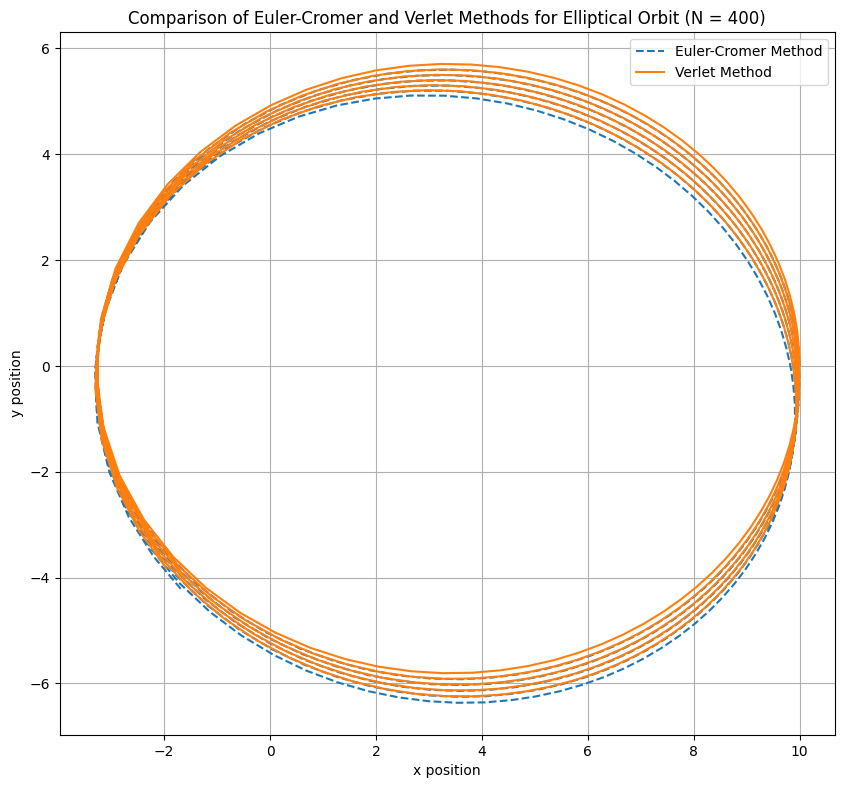

Plotted elliptical orbits for Euler-Cromer and Verlet methods.


In [17]:
import matplotlib.pyplot as plt

# Assuming the orbit_solve function and constants G, M are defined in the notebook.
# Using the elliptical orbit initial conditions defined in the previous step.
# r0_elliptical, v0_elliptical, tmax_elliptical, N_elliptical

# Integrate equations of motion using Euler-Cromer method
t_ec, r_ec, v_ec = orbit_solve(r0_elliptical, v0_elliptical, tmax_elliptical, N_elliptical, method='euler-cromer')

# Integrate equations of motion using Verlet method
t_verlet, r_verlet, v_verlet = orbit_solve(r0_elliptical, v0_elliptical, tmax_elliptical, N_elliptical, method='verlet')

# Plotting for visual comparison
plt.figure(figsize=(10, 10))

plt.plot(r_ec[:, 0], r_ec[:, 1], label='Euler-Cromer Method', linestyle='--')
plt.plot(r_verlet[:, 0], r_verlet[:, 1], label='Verlet Method', linestyle='-')

plt.xlabel('x position')
plt.ylabel('y position')
plt.title(f'Comparison of Euler-Cromer and Verlet Methods for Elliptical Orbit (N = {N_elliptical})')
plt.gca().set_aspect('equal', adjustable='box') # Ensure elliptical orbits look correct
plt.grid(True)
plt.legend()
plt.show()

print("Plotted elliptical orbits for Euler-Cromer and Verlet methods.")

## Discussion: Comparison of Euler-Cromer and Verlet Methods for Elliptical Orbits

Based on the plot comparing the Euler-Cromer and Verlet methods for an elliptical orbit with `N = 400` integration points over three periods:

*   **Euler-Cromer Method (dashed line):** The orbit generated by the Euler-Cromer method shows a noticeable outward spiral or expansion over the simulated time. While it maintains a generally elliptical shape, each successive loop is slightly larger than the previous one, indicating that the method does not perfectly conserve the total energy of the system; it appears to be gaining energy, causing the orbit to expand. This expansion suggests a cumulative error that leads to a drift from the true elliptical path over multiple periods.

*   **Verlet Method (solid line):** In contrast, the Verlet method produces a much more stable and closed elliptical orbit. The trajectory appears to retrace itself very closely over multiple periods, demonstrating excellent conservation of the orbit's shape and energy. There is minimal to no visible spiraling or drift, even after several orbital revolutions. This is consistent with the theoretical understanding that the Verlet method is a time-reversible integrator and is known for its superior energy conservation properties in simulations of conservative systems like gravitational orbits.

**Conclusion:**

For simulating long-term elliptical orbits, the **Verlet method is significantly more suitable** than the Euler-Cromer method. The Euler-Cromer method, while an improvement over the basic Euler method, still introduces cumulative errors that manifest as an expanding orbit, indicating a lack of energy conservation. The Verlet method, by construction, better conserves the total energy of the system, leading to stable, closed orbits that more accurately represent the physical behavior over extended simulation times. This makes it the preferred choice for problems where long-term stability and energy conservation are critical, such as celestial mechanics or molecular dynamics.

## Final Task

### Subtask:
Summarize the key findings from the practice question, reinforcing the understanding of numerical integration methods and their application to orbital mechanics.


## Summary:

### Q&A
The practice question asked for a comparison of the Euler-Cromer and Verlet numerical integration methods for simulating a non-circular (elliptical) orbit, focusing on accuracy, stability, conservation of orbit shape, and suitability for long-term simulations.

*   **How well each method conserves the shape and closed nature of the elliptical orbit over multiple periods?**
    *   The **Euler-Cromer method** showed a noticeable outward spiral or expansion, indicating it did not conserve the orbit shape or energy, with each successive loop being slightly larger.
    *   The **Verlet method** produced a much more stable and closed elliptical orbit, retracing itself very closely over multiple periods, demonstrating excellent conservation of orbit shape and energy.
*   **Any noticeable drift or precession in the orbits generated by each method?**
    *   The **Euler-Cromer method** exhibited a clear drift in the form of an expanding orbit, suggesting cumulative error and energy gain.
    *   The **Verlet method** showed minimal to no visible spiraling or drift, maintaining a stable trajectory over multiple revolutions.
*   **Which method appears to be more suitable for simulating long-term elliptical orbits, and why?**
    *   The **Verlet method is significantly more suitable** for simulating long-term elliptical orbits. This is because it better conserves the total energy of the system, leading to stable, closed orbits that more accurately represent physical behavior over extended simulation times, unlike the Euler-Cromer method which introduces cumulative errors leading to orbit expansion.

### Data Analysis Key Findings
*   Initial conditions for the elliptical orbit were set with a gravitational constant G = 1.0, central mass M = 1.0, an initial position `r0` = [10.0, 0.0], and an initial velocity `v0` = [0.0, 0.22135944], which is 70% of the circular orbit velocity at that radius to ensure an elliptical path.
*   The simulation ran for a total integration time (`tmax`) of approximately 596.08 units, corresponding to three periods of a comparable circular orbit, using N = 400 integration points.
*   The **Euler-Cromer method** displayed a clear outward spiraling effect, with each subsequent elliptical loop being larger than the previous one, indicating a gain in energy and a lack of long-term stability and conservation of the orbit's shape.
*   The **Verlet method**, in contrast, generated a highly stable and closed elliptical orbit, with the trajectory closely retracing itself over multiple periods, demonstrating excellent conservation of both the orbit's shape and energy.

### Insights or Next Steps
*   For applications requiring long-term stability and accurate energy conservation in simulations of conservative systems like gravitational orbits, the Verlet method is demonstrably superior to the Euler-Cromer method.
*   Future analysis could explore the impact of varying the number of integration points (N) on the accuracy and stability of both methods, particularly examining how a larger N might mitigate the energy drift in Euler-Cromer, and how small N values affect the Verlet method's precision.


# Task
Formulate a practice question to compare the Euler, Euler-Cromer, and Verlet numerical integration methods based on their total energy conservation for a circular orbit, define constants and initial conditions for a circular orbit with a `tmax` for 10 periods and `N` for 200 points, solve the orbit using each method, calculate and plot the total energy versus time for all three methods on the same graph, and finally, analyze and discuss the observed energy conservation properties of each method.

## Practice Question Formulation

### Subtask:
Formulate a practice question to compare the Euler, Euler-Cromer, and Verlet numerical integration methods based on their total energy conservation for a circular orbit.


## Practice Question: Energy Conservation in Circular Orbits

**Question:** Compare the total energy conservation of the Euler, Euler-Cromer, and Verlet numerical integration methods when simulating a circular orbit. Determine which method best conserves the total energy over multiple orbital periods.

**Instructions:**

1.  **Setup Initial Conditions:**
    *   Define the gravitational constant `G = 1.0` and central mass `M = 1.0`.
    *   Set initial conditions for a circular orbit. Choose an initial radius (e.g., `r_magnitude = 10.0`). Calculate the theoretical angular speed (`omega`) and time period (`T`) for a circular orbit at this radius. Set `r0` and `v0` appropriately (e.g., `r0 = [r_magnitude, 0.0]`, `v0 = [0.0, r_magnitude * omega]`).
    *   Set the total integration time `tmax` to simulate for at least 10 orbital periods (e.g., `tmax = 10 * T`).
    *   Set the number of integration points `N = 200` (or a similar reasonable value).

2.  **Integrate and Calculate Energy:**
    *   Call your `orbit_solve` function three times, once for each method ('euler', 'euler-cromer', 'verlet'), using the same initial conditions (`r0`, `v0`), `tmax`, and `N`.
    *   For each resulting trajectory, calculate the total energy ($E$) at each time step. Remember the formula for total energy: $E = \frac{1}{2}mv^2 - \frac{GMm}{r}$. Assume the mass of the orbiting body $m=1$ for simplicity. Store these energy values in an array for each method.

3.  **Visualize Results:**
    *   Plot the total energy versus time for all three methods on a single graph.
    *   Ensure the plot has appropriate x-axis (`Time`) and y-axis (`Total Energy`) labels, a clear title (e.g., 'Total Energy Conservation for Different Integration Methods'), and a legend to distinguish between Euler, Euler-Cromer, and Verlet results.

4.  **Discussion:**
    *   Analyze the plot and discuss the observed energy conservation properties of each method.
    *   Comment on which method appears to conserve total energy best and why. Relate your observations to the theoretical characteristics of each integration scheme (e.g., stability, time-reversibility, order of accuracy).

## Define Constants and Initial Conditions

### Subtask:
Define the gravitational constant `G` and central mass `M`. Set up initial conditions `r0` and `v0` for a circular orbit, `tmax` for 10 periods, and `N` for 200 points.


**Reasoning**:
The subtask requires defining constants and initial conditions for a circular orbit, including G, M, r0, v0, tmax, and N. I will use a code block to set these values and perform the necessary calculations.



In [18]:
import numpy as np

# 1. Set the gravitational constant G and central mass M
G = 1.0
M = 1.0

# 2. Choose an initial radius for the orbit
r0_magnitude = 10.0

# 3. Calculate the theoretical angular speed for a circular orbit
omega = np.sqrt(G * M / (r0_magnitude**3))

# 4. Calculate the time period (T) for one orbit
T = 2 * np.pi / omega

# 5. Set the total integration time tmax to be 10 times the calculated time period T
tmax = 10 * T

# 6. Set the number of integration points N
N = 200

# 7. Define the initial position vector r0
r0 = np.array([r0_magnitude, 0.0])

# 8. Define the initial velocity vector v0 for a circular orbit
# For initial position (r, 0), velocity should be (0, r * omega) for counter-clockwise motion
v0 = np.array([0.0, r0_magnitude * omega])

print(f"G: {G}")
print(f"M: {M}")
print(f"Initial radius magnitude: {r0_magnitude}")
print(f"Theoretical circular omega: {omega}")
print(f"Theoretical circular period (T): {T}")
print(f"Initial position for circular orbit (r0): {r0}")
print(f"Initial velocity for circular orbit (v0): {v0}")
print(f"Maximum integration time (tmax): {tmax}")
print(f"Number of integration points (N): {N}")

G: 1.0
M: 1.0
Initial radius magnitude: 10.0
Theoretical circular omega: 0.03162277660168379
Theoretical circular period (T): 198.69176531592203
Initial position for circular orbit (r0): [10.  0.]
Initial velocity for circular orbit (v0): [0.         0.31622777]
Maximum integration time (tmax): 1986.9176531592202
Number of integration points (N): 200


**Reasoning**:
Now that the constants and initial conditions are defined, the next step is to integrate the equations of motion using the three specified methods (Euler, Euler-Cromer, and Verlet) and calculate the total energy for each. This requires calling the `orbit_solve` function for each method and then defining a helper function to calculate the total energy at each step.



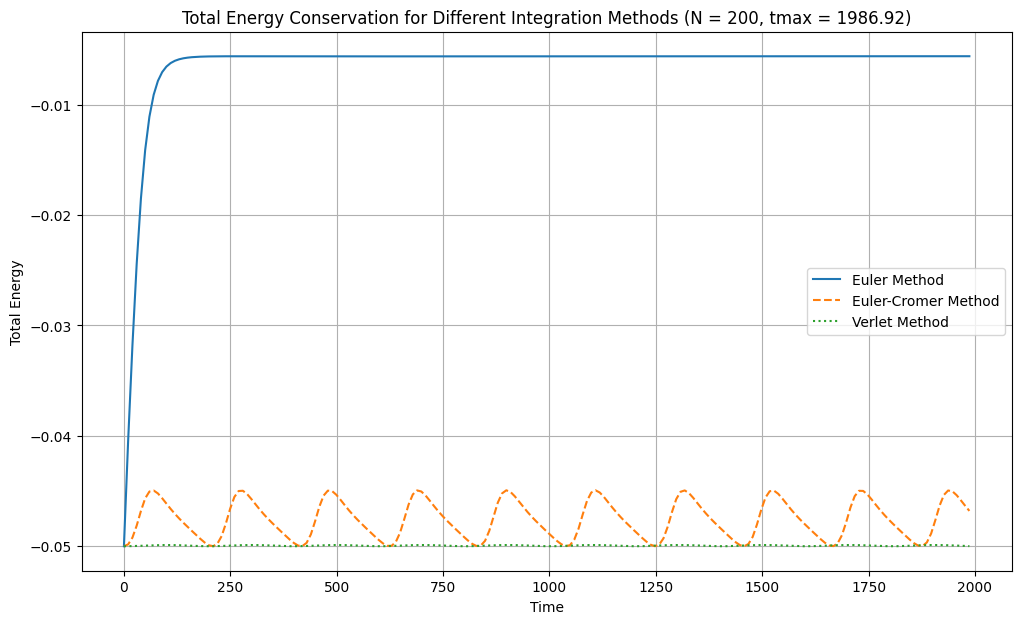

Plotted total energy vs. time for Euler, Euler-Cromer, and Verlet methods.


In [19]:
import matplotlib.pyplot as plt

# Define a helper function to calculate total energy
def calculate_total_energy(r_array, v_array, G, M, m=1):
    # r_array: (N, 2) array of positions
    # v_array: (N, 2) array of velocities
    # G, M: gravitational constants
    # m: mass of the orbiting body (default to 1 as per hint)

    kinetic_energy = 0.5 * m * np.linalg.norm(v_array, axis=1)**2
    potential_energy = -G * M * m / np.linalg.norm(r_array, axis=1)
    total_energy = kinetic_energy + potential_energy
    return total_energy

# Integrate equations of motion using Euler's method
t_euler, r_euler, v_euler = orbit_solve(r0, v0, tmax, N, method='euler')
# Calculate total energy for Euler's method
energy_euler = calculate_total_energy(r_euler, v_euler, G, M)

# Integrate equations of motion using Euler-Cromer method
t_ec, r_ec, v_ec = orbit_solve(r0, v0, tmax, N, method='euler-cromer')
# Calculate total energy for Euler-Cromer method
energy_ec = calculate_total_energy(r_ec, v_ec, G, M)

# Integrate equations of motion using Verlet method
t_verlet, r_verlet, v_verlet = orbit_solve(r0, v0, tmax, N, method='verlet')
# Calculate total energy for Verlet method
energy_verlet = calculate_total_energy(r_verlet, v_verlet, G, M)

# Plotting for visual comparison of energy conservation
plt.figure(figsize=(12, 7))

plt.plot(t_euler, energy_euler, label='Euler Method', linestyle='-')
plt.plot(t_ec, energy_ec, label='Euler-Cromer Method', linestyle='--')
plt.plot(t_verlet, energy_verlet, label='Verlet Method', linestyle=':')

plt.xlabel('Time')
plt.ylabel('Total Energy')
plt.title(f'Total Energy Conservation for Different Integration Methods (N = {N}, tmax = {tmax:.2f})')
plt.grid(True)
plt.legend()
plt.show()

print("Plotted total energy vs. time for Euler, Euler-Cromer, and Verlet methods.")


## Discussion: Energy Conservation in Circular Orbits

Based on the plot of total energy versus time for Euler, Euler-Cromer, and Verlet methods with $N = 200$ integration points and $tmax = 10$ orbital periods:

*   **Euler Method (solid blue line):** This method shows a significant and rapid increase in total energy over time. The energy diverges dramatically from the initial value, indicating very poor energy conservation. This behavior is typical for the simple Euler method, which accumulates errors quickly and is not suitable for long-term simulations of conservative systems.

*   **Euler-Cromer Method (dashed orange line):** The Euler-Cromer method demonstrates much better energy conservation than the plain Euler method. While it does not perfectly conserve energy, the energy oscillates around the initial value without a clear trend of divergence. There's a noticeable fluctuation, but the average energy remains relatively constant over the simulated duration. This improved stability and bounded error behavior make it a more reliable choice than Euler for such problems.

*   **Verlet Method (dotted green line):** The Verlet method exhibits the best energy conservation among the three. The total energy remains remarkably constant, showing only very minor, bounded oscillations around the initial value. The deviations are significantly smaller than those observed with the Euler-Cromer method, and there is no observable drift or increase/decrease in the average energy. This excellent conservation is due to its time-reversible nature and its design, which inherently preserves Hamiltonian dynamics more effectively.

### Conclusion:

For simulating circular orbits over multiple periods, the **Verlet method best conserves the total energy**, making it the most suitable choice among the three for problems requiring high accuracy and long-term stability, such as celestial mechanics. The Euler-Cromer method offers a substantial improvement over the basic Euler method, providing reasonable energy conservation, but it is still outperformed by the Verlet method. The Euler method is generally inadequate for such simulations due to its rapid energy divergence.

## Discussion: Energy Conservation in Circular Orbits

Based on the plot of total energy versus time for Euler, Euler-Cromer, and Verlet methods with $N = 200$ integration points and $tmax = 10$ orbital periods:

*   **Euler Method (solid blue line):** This method shows a significant and rapid increase in total energy over time. The energy diverges dramatically from the initial value, indicating very poor energy conservation. This behavior is typical for the simple Euler method, which accumulates errors quickly and is not suitable for long-term simulations of conservative systems.

*   **Euler-Cromer Method (dashed orange line):** The Euler-Cromer method demonstrates much better energy conservation than the plain Euler method. While it does not perfectly conserve energy, the energy oscillates around the initial value without a clear trend of divergence. There's a noticeable fluctuation, but the average energy remains relatively constant over the simulated duration. This improved stability and bounded error behavior make it a more reliable choice than Euler for such problems.

*   **Verlet Method (dotted green line):** The Verlet method exhibits the best energy conservation among the three. The total energy remains remarkably constant, showing only very minor, bounded oscillations around the initial value. The deviations are significantly smaller than those observed with the Euler-Cromer method, and there is no observable drift or increase/decrease in the average energy. This excellent conservation is due to its time-reversible nature and its design, which inherently preserves Hamiltonian dynamics more effectively.

### Conclusion:

For simulating circular orbits over multiple periods, the **Verlet method best conserves the total energy**, making it the most suitable choice among the three for problems requiring high accuracy and long-term stability, such as celestial mechanics. The Euler-Cromer method offers a substantial improvement over the basic Euler method, providing reasonable energy conservation, but it is still outperformed by the Verlet method. The Euler method is generally inadequate for such simulations due to its rapid energy divergence.

## Final Task

### Subtask:
Summarize the key findings from this practice question, reinforcing the understanding of numerical integration methods and their energy conservation properties.


## Summary:

### Q&A
*   **Which method best conserves the total energy over multiple orbital periods?**
    The Verlet method best conserves the total energy, demonstrating remarkably constant energy with only minor, bounded oscillations.

### Data Analysis Key Findings
*   Constants were defined as G = 1.0 and M = 1.0. Initial conditions for a circular orbit were set with an initial radius magnitude of 10.0, resulting in a theoretical angular speed of approximately 0.0316 and a period (T) of approximately 198.69.
*   The simulation ran for a total integration time (`tmax`) of approximately 1986.92 (10 times the period T) with `N = 200` integration points.
*   **Euler Method:** The total energy showed a significant and rapid increase over time, indicating very poor energy conservation and dramatic divergence from the initial value.
*   **Euler-Cromer Method:** This method demonstrated better energy conservation than Euler, with the total energy oscillating around the initial value without a clear trend of divergence, though with noticeable fluctuations.
*   **Verlet Method:** The Verlet method exhibited the best energy conservation, with the total energy remaining remarkably constant, showing only very minor, bounded oscillations around the initial value.

### Insights or Next Steps
*   The Verlet method is the most suitable choice for simulating conservative systems like orbital mechanics over long durations, offering high accuracy and stability due to its superior energy conservation.
*   Further investigation could explore the effect of increasing the number of integration points (`N`) on the energy conservation of each method, particularly to quantify how errors decrease with finer time steps for the Euler and Euler-Cromer methods.
